# ST456 Final Project: Short-Horizon Bitcoin Limit Order Book Forecasting

This notebook compares deep learning approaches to predicting short-horizon mid-price movements in Bitcoin limit order book (LOB) data, sampled at 250 ms intervals. Five models are evaluated: an OFI linear baseline, a Plain LSTM, DeepLOB, LiT, and DeepLOB v2, across three forecast horizons: 1 s, 2 s, and 5 s.


## 0. Drive mount & data preview

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
CSV_PATH = "/content/drive/MyDrive/1-09-1-20 2.csv"
preview_df = pd.read_csv(CSV_PATH, nrows=5)
print(preview_df.shape)
preview_df.head()


Mounted at /content/drive
(5, 43)


,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,32,33,34,35,36,37,38,39,40,41
0,0,1673302660926,2023-01-09 22:17:40,17181.6,23.371,17181.5,0.746,17181.4,5.428,17181.2,...,17182.2,5.168,17182.3,0.02,17182.4,6.692,17182.5,1.904,17182.6,2.546
1,1,1673302661177,2023-01-09 22:17:41,17181.6,24.232,17181.5,0.694,17181.4,5.428,17181.2,...,17182.2,6.043,17182.3,0.02,17182.4,6.001,17182.5,1.869,17182.6,2.105
2,2,1673302661427,2023-01-09 22:17:41,17181.6,24.403,17181.5,0.694,17181.4,5.428,17181.2,...,17182.2,6.043,17182.3,0.02,17182.4,6.012,17182.5,1.869,17182.6,2.713
3,3,1673302661678,2023-01-09 22:17:41,17181.6,24.874,17181.5,0.694,17181.4,5.428,17181.2,...,17182.2,6.043,17182.3,0.02,17182.4,6.001,17182.5,2.570,17182.6,2.613
4,4,1673302661928,2023-01-09 22:17:41,17181.6,24.403,17181.5,0.694,17181.4,5.428,17181.2,...,17182.2,6.043,17182.3,0.02,17182.4,6.001,17182.5,2.589,17182.6,2.591


## 1. Imports & Configuration

Standard libraries are imported alongside TensorFlow/Keras for modelling, scikit-learn for evaluation metrics and utilities for checkpointing and memory management. Seeds are fixed across Python, NumPy, and TensorFlow for reproducibility.
The LOB data has 10 levels, giving 40 features per snapshot (price and volume on each side). Snapshots are taken every 250 ms, with a lookback of T = 50. The three forecast horizons (1 s, 2 s, and 5 s) correspond to 4, 8, and 20 steps ahead respectively. The day-based train/val/test split uses days 1-3 for training, day 4 for validation, and day 5 for testing, with enough rows loaded to comfortably cover all five days plus boundary partials.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, glob, warnings, time, subprocess, random, gc, pickle
warnings.filterwarnings("ignore")
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, balanced_accuracy_score, log_loss,
)
from sklearn.utils.class_weight import compute_class_weight

# seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# checkpoints
CHECKPOINT_DIR = "/content/drive/MyDrive/st456_v6_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


In [ ]:
# settings
DATA_PATH = "/content/drive/MyDrive/1-09-1-20 2.csv"

NUM_LEVELS = 10
NUM_FEATURES = NUM_LEVELS * 2 * 2
SAMPLE_INTERVAL_MS = 250
T = 50

HORIZONS = [4, 8, 20]
HORIZON_LABELS = {4: "1s", 8: "2s", 20: "5s"}
CLASS_NAMES = ["Down", "Stationary", "Up"]

# split: train on first 3 full days, validate on day 4, test on day 5.
N_TRAIN_DAYS = 3
N_VAL_DAYS   = 1
N_TEST_DAYS  = 1
N_TOTAL_DAYS = N_TRAIN_DAYS + N_VAL_DAYS + N_TEST_DAYS

# load enough rows to cover N_TOTAL_DAYS plus a small buffer
ROWS_PER_DAY = int(24 * 3600 * 1000 / SAMPLE_INTERVAL_MS)
LOAD_ROWS    = int(N_TOTAL_DAYS * ROWS_PER_DAY * 1.2)

BATCH_SIZE = 256
MAX_EPOCHS = 50
PATIENCE = 8
LEAKY_RELU_ALPHA = 0.01

# define the different learning rates
LR_LSTM = 5e-4
LR_DEEPLOB = 1e-3
LR_LIT = 3e-4
LR_DLV2 = 5e-4
DEEPLOB_ADAM_EPSILON = 1e-7

print(f"Loading up to {LOAD_ROWS:,} rows to find {N_TOTAL_DAYS} full days "
      f"(~{ROWS_PER_DAY:,} rows/day)")


Loading up to 2,073,600 rows to find 5 full days (~345,600 rows/day)


## 2. Data Loading

The CSV is loaded in chunks to avoid memory issues, with each chunk standardised to a consistent column schema (row index, timestamp, datetime, then bid/ask price and volume for each of the 10 levels). Rows with incorrect timestamps are dropped. Mid-price and spread are then derived from the best bid and ask. The resulting mid-price and spread series are plotted before proceeding.


In [ ]:
# bid levels first then ask to match the raw csv layout
def _standardise_lob_columns(df):
    col_names = ["row_idx", "timestamp_ms", "datetime_str"]
    for i in range(1, NUM_LEVELS + 1):
        col_names.extend([f"bid_price_{i}", f"bid_vol_{i}"])
    for i in range(1, NUM_LEVELS + 1):
        col_names.extend([f"ask_price_{i}", f"ask_vol_{i}"])

    if df.shape[1] > len(col_names):
        df = df.iloc[:, :len(col_names)]

    df.columns = col_names[:df.shape[1]]
    return df

def load_lob_data(path, max_rows=None, chunksize=250_000):
    chunks, rows_kept = [], 0

    for chunk in pd.read_csv(path, on_bad_lines="skip", chunksize=chunksize):
        chunk = _standardise_lob_columns(chunk)

        # skip any rows with a malformed timestamp
        valid = chunk["datetime_str"].astype(str).str.match(
            r"^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}"
        )
        chunk = chunk[valid].copy()

        if chunk.empty:
            continue

        chunk["datetime"] = pd.to_datetime(chunk["datetime_str"], errors="coerce")
        chunk = chunk.dropna(subset=["datetime"])
        chunk["date"] = chunk["datetime"].dt.date

        if max_rows is not None:
            remaining = max_rows - rows_kept
            if len(chunk) >= remaining:
                chunks.append(chunk.iloc[:remaining])
                break

        chunks.append(chunk)
        rows_kept += len(chunk)

    return pd.concat(chunks, ignore_index=True)

raw_df = load_lob_data(DATA_PATH, max_rows=LOAD_ROWS)

# coerce any stray non numeric entries and drop incomplete rows
lob_cols = [c for c in raw_df.columns if "price" in c or "vol" in c]
raw_df[lob_cols] = raw_df[lob_cols].apply(pd.to_numeric, errors="coerce")
raw_df = raw_df.dropna(subset=lob_cols).reset_index(drop=True)

raw_df["mid_price"] = (raw_df["bid_price_1"] + raw_df["ask_price_1"]) / 2
raw_df["spread"] = raw_df["ask_price_1"] - raw_df["bid_price_1"]

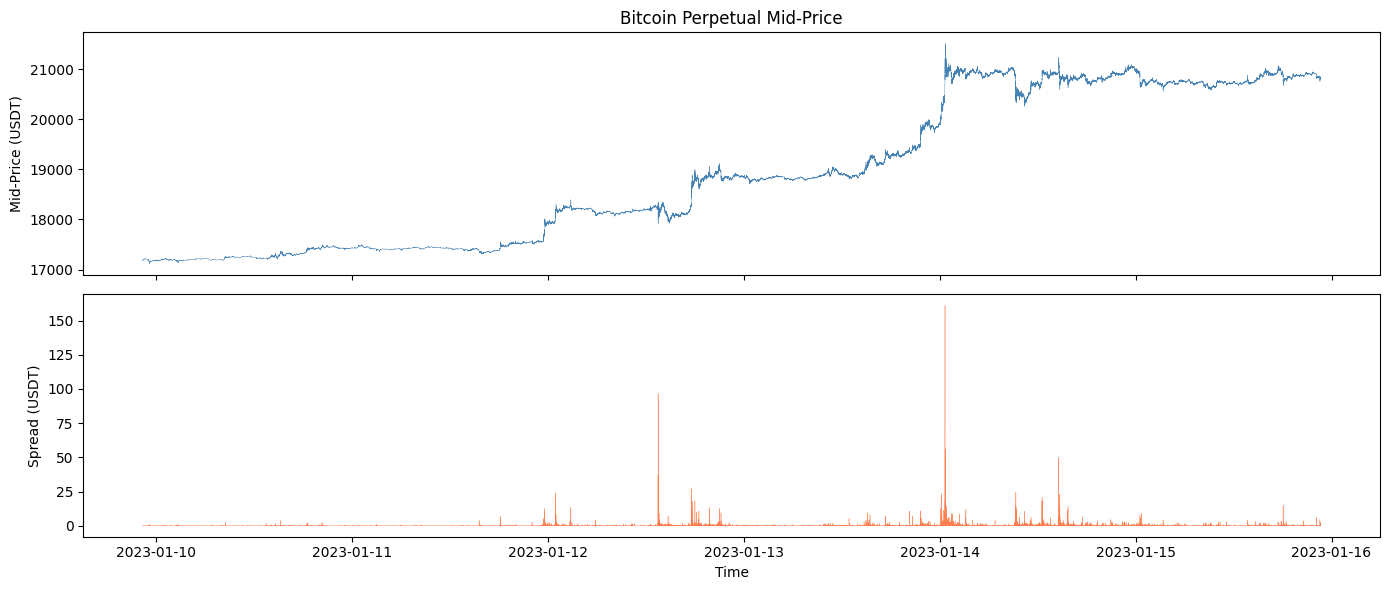

          mid_price        spread
count  2.073600e+06  2.073600e+06
mean   1.892130e+04  1.076599e-01
std    1.449799e+03  2.993027e-01
min    1.711835e+04  1.000000e-01
25%    1.742965e+04  1.000000e-01
50%    1.880995e+04  1.000000e-01
75%    2.072675e+04  1.000000e-01
max    2.151590e+04  1.610000e+02


In [ ]:
# plots
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(raw_df['datetime'], raw_df['mid_price'], linewidth=0.3, color='steelblue')
axes[0].set_ylabel('Mid-Price (USDT)'); axes[0].set_title('Bitcoin Perpetual Mid-Price')
axes[1].plot(raw_df['datetime'], raw_df['spread'],    linewidth=0.3, color='coral')
axes[1].set_ylabel('Spread (USDT)'); axes[1].set_xlabel('Time')
plt.tight_layout(); plt.show()
print(raw_df[['mid_price', 'spread']].describe())


## 3. Normalisation & Label Construction

Features are reordered into the DeepLOB format: {ask price, ask volume, bid price, bid volume, ... } cycling through all 10 levels, giving an (N, 40) array.

Normalisation follows a rolling z-score scheme where for each day the statistics are computed from available previous days, up to a 5-day rolling window. This  handles the non-stationarity of cryptocurrency price data, where a static normalisation would be inappropriate over multi-day windows.

Labels are constructed using a smoothed mid-price method where the percentage change is computed between the mean of the next k mid-prices and the mean of the previous k. A threshold α determines whether a point is labelled up (2), stationary (1), or down (0). Rather than fixing α at an absolute return threshold, a binary search is run on the training slice to find the value that produces roughly balanced classes, targeting 33% stationary labels. This calibration follows the protocol of Zhang, Zohren and Roberts (2019) introduced with the original DeepLOB paper. The classification task is therefore predicting whether a smoothed forward return exceeds a horizon-specific threshold tuned to the training distribution, rather than a universal directional label. The train/val/test split uses the first 3 full days for training, the 4th for validation, and the 5th for testing.



In [ ]:
# Reorder to DeepLOB format
feature_cols_ordered = []
for i in range(1, NUM_LEVELS + 1):
    feature_cols_ordered.extend([f'ask_price_{i}', f'ask_vol_{i}', f'bid_price_{i}', f'bid_vol_{i}'])

lob_data   = raw_df[feature_cols_ordered].values
mid_prices = raw_df['mid_price'].values
dates      = raw_df['date'].values
timestamps = raw_df['datetime'].values
print(f"LOB data shape: {lob_data.shape}")


LOB data shape: (2073600, 40)


In [ ]:
# rolling normalisation
unique_dates     = sorted(np.unique(dates))
lob_normalised   = np.zeros_like(lob_data, dtype=np.float64)

for d_idx, d in enumerate(unique_dates):
    mask_today = dates == d
    lookback_dates = unique_dates[max(0, d_idx - 5):d_idx] if d_idx > 0 else [d]
    hist_data = lob_data[np.isin(dates, lookback_dates)]
    mu = hist_data.mean(axis=0)
    sigma = hist_data.std(axis=0)
    sigma[sigma == 0] = 1
    lob_normalised[mask_today] = (lob_data[mask_today] - mu) / sigma

print(f"Normalised — mean range: [{lob_normalised.mean(axis=0).min():.3f}, {lob_normalised.mean(axis=0).max():.3f}]")
print(f"           — std  range: [{lob_normalised.std(axis=0).min():.3f},  {lob_normalised.std(axis=0).max():.3f}]")


Normalised — mean range: [-0.314, 3.836]
           — std  range: [0.835,  3.227]


In [ ]:
# labels
def compute_smoothed_labels(mid_prices, k, alpha):
    N  = len(mid_prices)
    cs = np.insert(np.cumsum(mid_prices), 0, 0)
    valid   = np.arange(k, N - k)
    m_minus = (cs[valid + 1]     - cs[valid - k])     / (k + 1)
    m_plus  = (cs[valid + k + 1] - cs[valid + 1])     / k
    l_t     = np.where(m_minus != 0, (m_plus - m_minus) / m_minus, 0.0)
    result  = np.ones(len(valid))
    result[l_t >  alpha] = 2
    result[l_t < -alpha] = 0
    labels = np.full(N, np.nan)
    labels[valid] = result
    return labels

def find_balanced_alpha_on_slice(mid_prices_full, k, slice_mask,
                                  target_stationary_frac=0.33, tol=0.03):
    lo, hi, best_alpha, best_diff = 1e-9, 1e-2, 1e-9, 1.0
    for _ in range(60):
        mid = (lo + hi) / 2
        labels = compute_smoothed_labels(mid_prices_full, k, mid)
        slice_labels = labels[slice_mask & ~np.isnan(labels)]
        if len(slice_labels) == 0:
            hi = mid; continue
        frac_stat = np.mean(slice_labels == 1)
        diff = abs(frac_stat - target_stationary_frac)
        if diff < best_diff:
            best_diff = diff; best_alpha = mid
        if   frac_stat > target_stationary_frac + tol: hi = mid
        elif frac_stat < target_stationary_frac - tol: lo = mid
        else: break
    return best_alpha


In [ ]:
N_total = len(raw_df)
unique_dates_sorted = sorted(np.unique(dates))

# find full days
day_row_counts = np.array([int((dates == d).sum()) for d in unique_dates_sorted])
full_day_threshold = 0.5 * day_row_counts.max()
full_days = [d for d, n in zip(unique_dates_sorted, day_row_counts) if n >= full_day_threshold]

print(f"Available dates ({len(unique_dates_sorted)}):")
for d, n in zip(unique_dates_sorted, day_row_counts):
    is_full = n >= full_day_threshold
    print(f"  {d}: {n:,} rows ({n / ROWS_PER_DAY * 24:.1f}h)" + ("" if is_full else "  [partial — dropped]"))

if len(full_days) < N_TOTAL_DAYS:
    raise RuntimeError(
        f"Need {N_TOTAL_DAYS} full days for the day split "
        f"({N_TRAIN_DAYS} train, {N_VAL_DAYS} val, {N_TEST_DAYS} test). "
        f"Only {len(full_days)} full days available. Increase LOAD_ROWS or check the data."
    )

# Take first N full days
selected_days = full_days[:N_TOTAL_DAYS]
train_days = selected_days[:N_TRAIN_DAYS]
val_days   = selected_days[N_TRAIN_DAYS : N_TRAIN_DAYS + N_VAL_DAYS]
test_days  = selected_days[N_TRAIN_DAYS + N_VAL_DAYS:]

train_mask = np.isin(dates, train_days)
val_mask   = np.isin(dates, val_days)
test_mask  = np.isin(dates, test_days)

print()
print("Split: day-based (v9 fix)")
print(f"  Train: {train_mask.sum():>9,} rows | days {train_days}")
print(f"  Val:   {val_mask.sum():>9,} rows | days {val_days}")
print(f"  Test:  {test_mask.sum():>9,} rows | days {test_days}")
print(f"\n  Total: {(train_mask | val_mask | test_mask).sum():,} rows ({N_total:,} loaded)")
dropped = N_total - (train_mask | val_mask | test_mask).sum()
if dropped > 0:
    print(f"  Dropped {dropped:,} rows")


Available dates (7):
  2023-01-09: 24,499 rows (1.7h)  [partial — dropped]
  2023-01-10: 344,799 rows (23.9h)
  2023-01-11: 344,339 rows (23.9h)
  2023-01-12: 344,549 rows (23.9h)
  2023-01-13: 344,628 rows (23.9h)
  2023-01-14: 344,616 rows (23.9h)
  2023-01-15: 326,170 rows (22.7h)

Split: day-based (v9 fix)
  Train: 1,033,687 rows | days [datetime.date(2023, 1, 10), datetime.date(2023, 1, 11), datetime.date(2023, 1, 12)]
  Val:     344,628 rows | days [datetime.date(2023, 1, 13)]
  Test:    344,616 rows | days [datetime.date(2023, 1, 14)]

  Total: 1,722,931 rows (2,073,600 loaded)
  Dropped 350,669 rows from partial / unselected days


In [ ]:
# labels
all_labels, alphas = {}, {}

for k in HORIZONS:
    alpha = find_balanced_alpha_on_slice(mid_prices, k, train_mask)
    all_labels[k] = compute_smoothed_labels(mid_prices, k, alpha)
    alphas[k] = alpha


## 4. Dataset Construction & Evaluation Utilities

Three dataset builders wrap a shared sequence constructor. The core function slides a window of length T over the LOB array, keeping only candidates where all T lookback rows and all k future rows fall within the same split mask, making sure there is no leakage across day boundaries. DeepLOB adds a channel dimension for the convolutional layers, while LiT reshapes the data into (N, 20, T, 2), separating price and volume into two channels and grouping ask and bid levels.

The evaluation helper runs model predictions and computes accuracy, balanced accuracy, weighted and macro F1, precision and recall. Training callbacks are shared across all models. Early stopping and learning rate reduction both monitor validation loss, with the best weights restored after stopping. Class weights are computed from the training labels to handle the imbalance between up, down, and stationary.


In [ ]:
# dataset builders
def _valid_candidates(labels, mask, T, k):
    candidate = np.where(mask & ~np.isnan(labels))[0]
    candidate = candidate[(candidate >= T - 1) & (candidate + k < len(mask))]
    if len(candidate) == 0:
        return candidate
    cs = np.insert(np.cumsum(mask.astype(np.int32)), 0, 0)
    input_sums  = cs[candidate + 1]     - cs[candidate - T + 1]
    future_sums = cs[candidate + k + 1] - cs[candidate + 1]
    return candidate[(input_sums == T) & (future_sums == k)]

def create_sequence_dataset(lob_data, labels, mask, T=50, k=1):
    candidate = _valid_candidates(labels, mask, T, k)
    if len(candidate) == 0:
        return np.empty((0, T, lob_data.shape[1]), dtype=np.float32), np.empty((0,), dtype=np.int64)
    X_seq = np.stack([lob_data[idx - T + 1 : idx + 1] for idx in candidate]).astype(np.float32)
    y = labels[candidate].astype(np.int64)
    return X_seq, y

# dataset wrappers
def create_lstm_dataset(lob_data, labels, mask, T=50, k=1):
    return create_sequence_dataset(lob_data, labels, mask, T, k)

def create_deeplob_dataset(lob_data, labels, mask, T=50, k=1):
    X, y = create_sequence_dataset(lob_data, labels, mask, T, k)
    return X[..., np.newaxis], y

def create_lit_dataset(lob_data, labels, mask, T=50, k=1):
    X, y = create_sequence_dataset(lob_data, labels, mask, T, k)
    if len(X) == 0:
        return np.empty((0, 20, T, 2), dtype=np.float32), y

    # index lists grouped by side
    ask_price_idx = [4 * n     for n in range(NUM_LEVELS)]
    ask_vol_idx   = [4 * n + 1 for n in range(NUM_LEVELS)]
    bid_price_idx = [4 * n + 2 for n in range(NUM_LEVELS)]
    bid_vol_idx   = [4 * n + 3 for n in range(NUM_LEVELS)]

    price_idx = ask_price_idx + bid_price_idx
    vol_idx   = ask_vol_idx   + bid_vol_idx

    X_prices = np.transpose(X[:, :, price_idx], (0, 2, 1))
    X_vols   = np.transpose(X[:, :, vol_idx],   (0, 2, 1))

    # stack so channel 0 = price, channel 1 = volume, shape (N, 20, T, 2)
    return np.stack([X_prices, X_vols], axis=-1).astype(np.float32), y

# Evaluation helper
def evaluate_model(model, X, y, batch_size=256):
    probs = model.predict(X, batch_size=batch_size, verbose=0)
    yp    = np.argmax(probs, axis=1)
    return {
        "accuracy":            accuracy_score(y, yp),
        "balanced_accuracy":   balanced_accuracy_score(y, yp),
        "f1_weighted":         f1_score(y, yp, average="weighted", zero_division=0),
        "f1_macro":            f1_score(y, yp, average="macro",    zero_division=0),
        "precision_weighted":  precision_score(y, yp, average="weighted", zero_division=0),
        "recall_weighted":     recall_score(y, yp,    average="weighted", zero_division=0),
        "y_test": y, "y_pred": yp,
    }

def summarise_keras_history(history, horizon):
    h = history.history
    return {
        "horizon":         horizon,
        "final_train_loss": h["loss"][-1],
        "final_val_loss":   h["val_loss"][-1],
        "best_val_loss":    float(np.min(h["val_loss"])),
        "best_val_epoch":   int(np.argmin(h["val_loss"])) + 1,
    }

def make_callbacks():
    return [
        EarlyStopping(monitor="val_loss", mode="min", patience=PATIENCE,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5,
                          min_lr=1e-6, verbose=1),
    ]

def get_class_weights(y_train):
    cw = compute_class_weight(class_weight="balanced", classes=np.array([0, 1, 2]), y=y_train)
    return {int(c): float(w) for c, w in zip([0, 1, 2], cw)}

def plot_performance(summary_df, title):
    x = summary_df["horizon"].astype(str)
    fig, ax1 = plt.subplots(figsize=(10, 5))
    for metric, label in [("accuracy","Accuracy"),("balanced_accuracy","Balanced Acc"),
                           ("f1_weighted","Weighted F1"),("f1_macro","Macro F1")]:
        ax1.plot(x, summary_df[metric], marker="o", linewidth=2, label=label)
    ax1.set_xlabel("Horizon"); ax1.set_ylabel("Test Score"); ax1.set_ylim(0, 1); ax1.grid(alpha=0.3)
    ax2 = ax1.twinx()
    for metric, label, ls in [("final_train_loss","Train loss","--"),
                               ("final_val_loss","Val loss","--"),
                               ("best_val_loss","Best val loss",":")]:
        ax2.plot(x, summary_df[metric], marker="x", linestyle=ls, linewidth=1.8, label=label)
    ax2.set_ylabel("Cross-Entropy Loss")
    h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1+h2, l1+l2, loc="best", fontsize=8)
    plt.title(title); plt.tight_layout(); plt.show()

def build_results_summary(results_dict, history_dict=None):
    horizon_order = [HORIZON_LABELS[k] for k in HORIZONS]
    df = pd.DataFrame([{**results_dict[k], "horizon": HORIZON_LABELS[k]} for k in HORIZONS])
    df["horizon"] = pd.Categorical(df["horizon"], categories=horizon_order, ordered=True)
    df = df.sort_values("horizon")
    if history_dict is not None:
        loss_df = pd.DataFrame([summarise_keras_history(history_dict[k], HORIZON_LABELS[k]) for k in HORIZONS])
        loss_df["horizon"] = pd.Categorical(loss_df["horizon"], categories=horizon_order, ordered=True)
        df = pd.merge(df, loss_df.sort_values("horizon"), on="horizon")
    return df

DISPLAY_COLS = ["model","horizon","accuracy","balanced_accuracy","f1_weighted","f1_macro",
                "final_train_loss","final_val_loss","best_val_loss","best_val_epoch"]


## 5. Model 1 — Order Flow Imbalance (OFI) Linear Baseline

The OFI (Order Flow Imbalance) baseline provides a linear benchmark for comparison against the deep learning models. For each of the 10 LOB levels, OFI is computed as the difference between the bid and ask side flow, capturing the net pressure from arriving orders at each level. The cumulative OFI over the lookback window T is then used as the feature vector for a logistic regression classifier with balanced class weights.

The model is trained and evaluated separately for each forecast horizon, with log loss used as the reported loss metric to keep it comparable with the neural models. Results are pickled to Drive after each horizon.


In [ ]:
# OFI baseline
def compute_ofi_features(lob_data_raw, num_levels=NUM_LEVELS):
    N   = lob_data_raw.shape[0]
    ofi = np.zeros((N, num_levels), dtype=np.float64)
    for n in range(num_levels):
        ask_p = lob_data_raw[:, 4*n];     ask_v = lob_data_raw[:, 4*n+1]
        bid_p = lob_data_raw[:, 4*n+2];  bid_v = lob_data_raw[:, 4*n+3]
        ask_p_prev = np.roll(ask_p, 1); ask_p_prev[0] = ask_p[0]
        ask_v_prev = np.roll(ask_v, 1); ask_v_prev[0] = ask_v[0]
        bid_p_prev = np.roll(bid_p, 1); bid_p_prev[0] = bid_p[0]
        bid_v_prev = np.roll(bid_v, 1); bid_v_prev[0] = bid_v[0]
        W_n = bid_v*(bid_p>=bid_p_prev) - bid_v_prev*(bid_p<=bid_p_prev)
        V_n = ask_v*(ask_p<=ask_p_prev) - ask_v_prev*(ask_p>=ask_p_prev)
        ofi[:, n] = W_n.astype(float) - V_n.astype(float)
    ofi[0, :] = 0.0
    return ofi

def create_ofi_dataset(ofi_data, labels, mask, T=50, k=1):
    candidate = _valid_candidates(labels, mask, T, k)
    if len(candidate) == 0:
        return np.empty((0, ofi_data.shape[1]), dtype=np.float32), np.empty((0,), dtype=np.int64)
    cum = np.insert(np.cumsum(ofi_data, axis=0), 0, 0.0, axis=0)
    X   = (cum[candidate + 1] - cum[candidate - T + 1]).astype(np.float32)
    return X, labels[candidate].astype(np.int64)

class OFILogisticBaseline:
    def fit(self, X, y_int):
        self.mean_ = X.mean(axis=0); self.std_ = X.std(axis=0); self.std_[self.std_ == 0] = 1
        self.clf_  = LogisticRegression(solver="lbfgs", max_iter=1000,
                                        class_weight="balanced", C=1.0)
        self.clf_.fit((X - self.mean_) / self.std_, y_int)
    def predict_proba(self, X):
        return self.clf_.predict_proba((X - self.mean_) / self.std_)
    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

ofi_data = compute_ofi_features(lob_data, num_levels=NUM_LEVELS)
print(f"OFI shape: {ofi_data.shape}")


OFI shape: (2073600, 10)



OFI k=4 (1s)
Train: (1033634, 10)  Val: (344575, 10)  Test: (344563, 10)
Train class dist: [187178 664391 182065]
Accuracy: 0.4304  |  Balanced Acc: 0.4439  |  Macro F1: 0.4310
              precision    recall  f1-score   support

        Down     0.5248    0.3625    0.4288    126334
  Stationary     0.3238    0.5741    0.4141     90850
          Up     0.5230    0.3951    0.4502    127379

    accuracy                         0.4304    344563
   macro avg     0.4572    0.4439    0.4310    344563
weighted avg     0.4712    0.4304    0.4328    344563


OFI k=8 (2s)
Train: (1033630, 10)  Val: (344571, 10)  Test: (344559, 10)
Train class dist: [253154 531990 248486]
Accuracy: 0.4102  |  Balanced Acc: 0.4644  |  Macro F1: 0.4025
              precision    recall  f1-score   support

        Down     0.6081    0.3612    0.4532    149914
  Stationary     0.1771    0.6400    0.2775     43780
          Up     0.6079    0.3920    0.4767    150865

    accuracy                         0.4102  

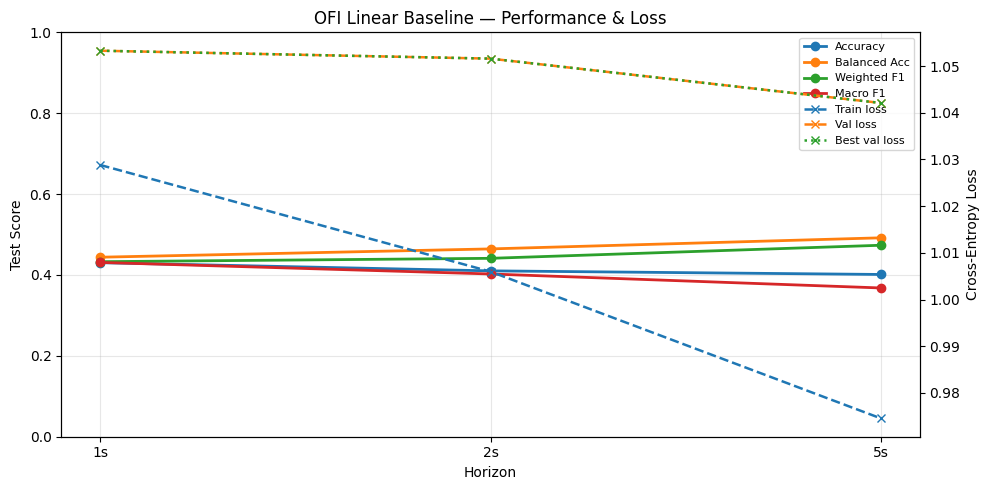

,model,horizon,accuracy,balanced_accuracy,f1_weighted,f1_macro,final_train_loss,final_val_loss,best_val_loss,best_val_epoch
0,OFI Linear,1s,0.4304,0.4439,0.4328,0.4310,1.0288,1.0533,1.0533,1
1,OFI Linear,2s,0.4102,0.4644,0.4412,0.4025,1.0060,1.0516,1.0516,1
2,OFI Linear,5s,0.4013,0.4919,0.4735,0.3679,0.9745,1.0421,1.0421,1


In [ ]:
ofi_results, ofi_histories = {}, {}

for k in HORIZONS:
    print(f"\nOFI k={k} ({HORIZON_LABELS[k]})")
    Xtr, ytr = create_ofi_dataset(ofi_data, all_labels[k], train_mask, T, k)
    Xva, yva = create_ofi_dataset(ofi_data, all_labels[k], val_mask,   T, k)
    Xte, yte = create_ofi_dataset(ofi_data, all_labels[k], test_mask,  T, k)
    print(f"Train: {Xtr.shape}  Val: {Xva.shape}  Test: {Xte.shape}")
    print(f"Train class dist: {np.bincount(ytr, minlength=3)}")

    model = OFILogisticBaseline()
    model.fit(Xtr, ytr)

    probs_tr = model.predict_proba(Xtr); probs_va = model.predict_proba(Xva)
    probs_te = model.predict_proba(Xte); ypred = np.argmax(probs_te, axis=1)

    ofi_results[k] = {"model": "OFI Linear", "horizon": HORIZON_LABELS[k],
                      **{m: f(yte, ypred) for m, f in [
                          ("accuracy",           accuracy_score),
                          ("balanced_accuracy",  balanced_accuracy_score),
                          ("f1_weighted",        lambda a,b: f1_score(a,b,average="weighted",zero_division=0)),
                          ("f1_macro",           lambda a,b: f1_score(a,b,average="macro",zero_division=0)),
                          ("precision_weighted", lambda a,b: precision_score(a,b,average="weighted",zero_division=0)),
                          ("recall_weighted",    lambda a,b: recall_score(a,b,average="weighted",zero_division=0)),
                      ]},
                      "y_test": yte, "y_pred": ypred,
                      "final_train_loss": log_loss(ytr, probs_tr, labels=[0,1,2]),
                      "final_val_loss":   log_loss(yva, probs_va, labels=[0,1,2]),
                      "best_val_loss":    log_loss(yva, probs_va, labels=[0,1,2]),
                      "best_val_epoch":   1}
    ofi_histories[k] = {"loss": [ofi_results[k]["final_train_loss"]],
                        "val_loss": [ofi_results[k]["final_val_loss"]]}

    print(f"Accuracy: {ofi_results[k]['accuracy']:.4f}  |  Balanced Acc: {ofi_results[k]['balanced_accuracy']:.4f}  |  Macro F1: {ofi_results[k]['f1_macro']:.4f}")
    print(classification_report(yte, ypred, target_names=CLASS_NAMES, digits=4, zero_division=0))

    del Xtr, ytr, Xva, yva, Xte, probs_tr, probs_va, probs_te; gc.collect()

with open(f"{CHECKPOINT_DIR}/ofi_results.pkl", "wb") as f:
    pickle.dump({"results": ofi_results, "histories": ofi_histories}, f)
print("Saved OFI results")

summary_ofi = build_results_summary(ofi_results)
summary_ofi["final_train_loss"] = [ofi_results[k]["final_train_loss"] for k in HORIZONS]
summary_ofi["final_val_loss"]   = [ofi_results[k]["final_val_loss"]   for k in HORIZONS]
summary_ofi["best_val_loss"]    = summary_ofi["final_val_loss"]
summary_ofi["best_val_epoch"]   = 1
plot_performance(summary_ofi, "OFI Linear Baseline — Performance & Loss")
display(summary_ofi[DISPLAY_COLS].round(4))


## 6. Model 2 — Plain LSTM

The plain LSTM serves as a neural baseline sitting between the linear OFI model and the full DeepLOB architecture. It takes the raw normalised LOB sequence of shape (T, 40) and passes it through a single LSTM layer of 64 units followed by a dropout layer and a softmax output. No convolutional feature extraction is performed, so the model must learn directly from the raw price and volume sequence. The model trained on the 1s horizon is kept for later use.

In [ ]:
def build_plain_lstm(T=50, num_features=40, num_classes=3, lstm_units=64, dropout_rate=0.2):
    inp = layers.Input(shape=(T, num_features), name="lob_sequence")
    x   = layers.LSTM(lstm_units, name="lstm")(inp)
    x   = layers.Dropout(dropout_rate)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inp, out, name="Plain_LSTM")



Plain LSTM k=4 (1s)
Train: (1033634, 50, 40)  Val: (344575, 50, 40)  Test: (344563, 50, 40)
Class weights: {0: 1.8407327071913722, 1: 0.5185871973983192, 2: 1.8924266974249124}
Epoch 1/50
4038/4038 - 32s - 8ms/step - accuracy: 0.7162 - loss: 0.6175 - val_accuracy: 0.7311 - val_loss: 0.6257 - learning_rate: 5.0000e-04
Epoch 2/50
4038/4038 - 28s - 7ms/step - accuracy: 0.7592 - loss: 0.5523 - val_accuracy: 0.7400 - val_loss: 0.6033 - learning_rate: 5.0000e-04
Epoch 3/50
4038/4038 - 28s - 7ms/step - accuracy: 0.7718 - loss: 0.5336 - val_accuracy: 0.7482 - val_loss: 0.5911 - learning_rate: 5.0000e-04
Epoch 4/50
4038/4038 - 28s - 7ms/step - accuracy: 0.7790 - loss: 0.5229 - val_accuracy: 0.7510 - val_loss: 0.5851 - learning_rate: 5.0000e-04
Epoch 5/50
4038/4038 - 28s - 7ms/step - accuracy: 0.7844 - loss: 0.5144 - val_accuracy: 0.7500 - val_loss: 0.5856 - learning_rate: 5.0000e-04
Epoch 6/50
4038/4038 - 28s - 7ms/step - accuracy: 0.7883 - loss: 0.5086 - val_accuracy: 0.7547 - val_loss: 0.578

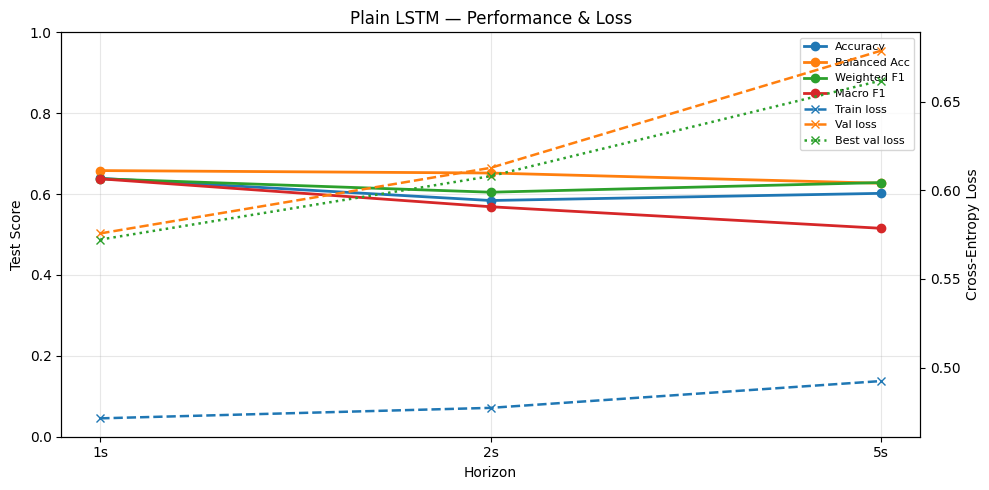

,model,horizon,accuracy,balanced_accuracy,f1_weighted,f1_macro,final_train_loss,final_val_loss,best_val_loss,best_val_epoch
0,Plain LSTM,1s,0.6390,0.6581,0.6378,0.6378,0.4713,0.5757,0.5722,9
1,Plain LSTM,2s,0.5841,0.6521,0.6047,0.5687,0.4773,0.6126,0.6079,6
2,Plain LSTM,5s,0.6018,0.6268,0.6285,0.5154,0.4924,0.6787,0.6619,4


In [ ]:
# Train and evaluate Plain LSTM across all horizons
lstm_results, lstm_histories = {}, {}

for k in HORIZONS:
    print(f"\nPlain LSTM k={k} ({HORIZON_LABELS[k]})")
    Xtr, ytr = create_lstm_dataset(lob_normalised, all_labels[k], train_mask, T, k)
    Xva, yva = create_lstm_dataset(lob_normalised, all_labels[k], val_mask,   T, k)
    Xte, yte = create_lstm_dataset(lob_normalised, all_labels[k], test_mask,  T, k)
    print(f"Train: {Xtr.shape}  Val: {Xva.shape}  Test: {Xte.shape}")
    cw = get_class_weights(ytr)
    print(f"Class weights: {cw}")

    model = build_plain_lstm(T=T, num_features=NUM_FEATURES, num_classes=3)
    model.compile(optimizer=Adam(learning_rate=LR_LSTM),
                  loss="categorical_crossentropy", metrics=["accuracy"])
    history = model.fit(Xtr, to_categorical(ytr, 3),
                        batch_size=BATCH_SIZE, epochs=MAX_EPOCHS,
                        validation_data=(Xva, to_categorical(yva, 3)),
                        class_weight=cw, callbacks=make_callbacks(), verbose=2)

    lstm_results[k] = {"model": "Plain LSTM", **evaluate_model(model, Xte, yte, BATCH_SIZE)}
    lstm_histories[k] = history

    print(f"Accuracy: {lstm_results[k]['accuracy']:.4f}  |  Macro F1: {lstm_results[k]['f1_macro']:.4f}")
    print(classification_report(yte, lstm_results[k]['y_pred'], target_names=CLASS_NAMES, digits=4, zero_division=0))

    if k == 4:
        ft_pretrained_lstm = model
    else:
        del model
    del Xtr, ytr, Xva, yva, Xte, yte; tf.keras.backend.clear_session(); gc.collect()

with open(f"{CHECKPOINT_DIR}/lstm_results.pkl", "wb") as f:
    pickle.dump({"results": lstm_results, "histories": {k: h.history for k, h in lstm_histories.items()}}, f)
print("Saved Plain LSTM results")

summary_lstm = build_results_summary(lstm_results, lstm_histories)
plot_performance(summary_lstm, "Plain LSTM — Performance & Loss")
display(summary_lstm[DISPLAY_COLS].round(4))


## 7. Model 3 — DeepLOB

The DeepLOB architecture (Zhang, Zohren and Roberts, 2019) processes the LOB input of shape (T, 40, 1) through three convolutional blocks before passing the extracted features into an Inception module and a final LSTM layer.
The three convolutional blocks progressively compress the level dimension. The first block applies a (1×2) strided convolution that pairs price and volume at each level on a single side of the book (40 to 20). The second combines two adjacent (price, volume) pair outputs with another (1×2) strided convolution (20 to 10), and the third aggregates across all 10 remaining positions with a (1×10) filter down to a single feature map. The strided design is what makes the price-volume coupling explicit, since a kernel width of two with stride two ensures each filter sees one (price, volume) pair at one level rather than mixing across levels or sides. Each strided convolution is followed by two temporal (4×1) convolutions with Leaky ReLU activations (α = 0.01) and batch normalisation.


The Inception module (Szegedy et al., 2015) then processes the compressed representation using three parallel branches. The first is a 3×1 temporal convolution preceded by a 1×1 bottleneck, the second is a 5×1 temporal convolution and the third is a max pooling branch. The three branches together capture patterns at multiple timescales (~750 ms and ~1.25 s) while the max-pool branch isolates the dominant feature activation. The outputs are concatenated and reshaped before being passed to a 64 unit LSTM, whose final state feeds a softmax output layer. We use Adam with lr = 1e-3 and ε = 1e-7 rather than the original paper's lr = 1e-2 and ε = 1, because the latter setting was tuned for FI-2010 (event-sampled equities) and produced validation-loss oscillation on uniform-time crypto data, where the per-step gradient signal is noisier. Weights and results are checkpointed to Drive after each horizon, and the model trained on the 1s horizon is kept for later use in the fine-tuning section.


In [ ]:
def build_deeplob(T=50, num_features=40, num_classes=3, leaky_alpha=0.01):
    def conv_bn(x, filters, kernel):
        x = layers.Conv2D(filters, kernel, padding='same')(x)
        x = layers.LeakyReLU(alpha=leaky_alpha)(x)
        return layers.BatchNormalization()(x)

    inputs = layers.Input(shape=(T, num_features, 1))

    # Block 1: pair price+vol per level  (40 → 20)
    x = layers.Conv2D(16, (1, 2), strides=(1, 2), padding='valid')(inputs)
    x = layers.LeakyReLU(alpha=leaky_alpha)(x); x = layers.BatchNormalization()(x)
    x = conv_bn(x, 16, (4, 1)); x = conv_bn(x, 16, (4, 1))

    # Block 2: combine ask/bid per level (20 → 10)
    x = layers.Conv2D(16, (1, 2), strides=(1, 2), padding='valid')(x)
    x = layers.LeakyReLU(alpha=leaky_alpha)(x); x = layers.BatchNormalization()(x)
    x = conv_bn(x, 16, (4, 1)); x = conv_bn(x, 16, (4, 1))

    # Block 3: aggregate across all 10 levels (10 → 1)
    x = layers.Conv2D(16, (1, 10), padding='valid')(x)
    x = layers.LeakyReLU(alpha=leaky_alpha)(x); x = layers.BatchNormalization()(x)
    x = conv_bn(x, 16, (4, 1)); x = conv_bn(x, 16, (4, 1))

    # Inception module: multi-timescale feature extraction
    b1 = conv_bn(conv_bn(x, 32, (1, 1)), 32, (3, 1))
    b2 = conv_bn(conv_bn(x, 32, (1, 1)), 32, (5, 1))
    b3 = conv_bn(layers.MaxPooling2D((3, 1), strides=(1, 1), padding='same')(x), 32, (1, 1))
    x  = layers.Concatenate(axis=-1)([b1, b2, b3])  # (T, 1, 96)

    x   = layers.Reshape((T, -1))(x)
    x   = layers.LSTM(64)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return Model(inputs, out, name='DeepLOB')



DeepLOB k=4 (1s)
Train: (1033634, 50, 40, 1)  Val: (344575, 50, 40, 1)  Test: (344563, 50, 40, 1)
Class weights: {0: 1.8407327071913722, 1: 0.5185871973983192, 2: 1.8924266974249124}
Epoch 1/50
4038/4038 - 122s - 30ms/step - accuracy: 0.7880 - loss: 0.5183 - val_accuracy: 0.7729 - val_loss: 0.5485 - learning_rate: 0.0010
Epoch 2/50
4038/4038 - 105s - 26ms/step - accuracy: 0.8146 - loss: 0.4714 - val_accuracy: 0.7788 - val_loss: 0.5348 - learning_rate: 0.0010
Epoch 3/50
4038/4038 - 105s - 26ms/step - accuracy: 0.8211 - loss: 0.4594 - val_accuracy: 0.7786 - val_loss: 0.5343 - learning_rate: 0.0010
Epoch 4/50
4038/4038 - 105s - 26ms/step - accuracy: 0.8249 - loss: 0.4517 - val_accuracy: 0.7753 - val_loss: 0.5393 - learning_rate: 0.0010
Epoch 5/50
4038/4038 - 105s - 26ms/step - accuracy: 0.8266 - loss: 0.4455 - val_accuracy: 0.7783 - val_loss: 0.5338 - learning_rate: 0.0010
Epoch 6/50
4038/4038 - 105s - 26ms/step - accuracy: 0.8280 - loss: 0.4396 - val_accuracy: 0.7683 - val_loss: 0.5526 

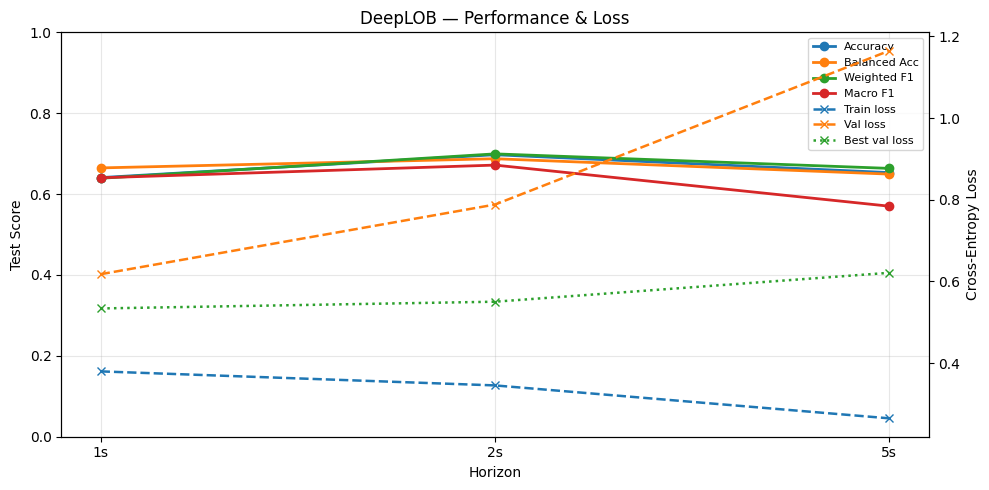

,model,horizon,accuracy,balanced_accuracy,f1_weighted,f1_macro,final_train_loss,final_val_loss,best_val_loss,best_val_epoch
0,DeepLOB,1s,0.6408,0.6648,0.6391,0.6403,0.3797,0.6177,0.5338,5
1,DeepLOB,2s,0.6973,0.6874,0.6995,0.6717,0.3454,0.7882,0.5503,2
2,DeepLOB,5s,0.6531,0.6494,0.6635,0.5701,0.2648,1.1648,0.6211,2


In [ ]:
# Train and evaluate DeepLOB across all horizons
deeplob_results, deeplob_histories = {}, {}

for k in HORIZONS:
    print(f"\nDeepLOB k={k} ({HORIZON_LABELS[k]})")
    Xtr, ytr = create_deeplob_dataset(lob_normalised, all_labels[k], train_mask, T, k)
    Xva, yva = create_deeplob_dataset(lob_normalised, all_labels[k], val_mask,   T, k)
    Xte, yte = create_deeplob_dataset(lob_normalised, all_labels[k], test_mask,  T, k)
    print(f"Train: {Xtr.shape}  Val: {Xva.shape}  Test: {Xte.shape}")
    cw = get_class_weights(ytr)
    print(f"Class weights: {cw}")

    model = build_deeplob(T=T, num_features=NUM_FEATURES, num_classes=3)
    model.compile(optimizer=Adam(learning_rate=LR_DEEPLOB, epsilon=DEEPLOB_ADAM_EPSILON),
                  loss="categorical_crossentropy", metrics=["accuracy"])
    history = model.fit(Xtr, to_categorical(ytr, 3),
                        batch_size=BATCH_SIZE, epochs=MAX_EPOCHS,
                        validation_data=(Xva, to_categorical(yva, 3)),
                        class_weight=cw, callbacks=make_callbacks(), verbose=2)

    deeplob_results[k] = {"model": "DeepLOB", **evaluate_model(model, Xte, yte, BATCH_SIZE)}
    deeplob_histories[k] = history

    print(f"Accuracy: {deeplob_results[k]['accuracy']:.4f}  |  Macro F1: {deeplob_results[k]['f1_macro']:.4f}")
    print(classification_report(yte, deeplob_results[k]['y_pred'], target_names=CLASS_NAMES, digits=4, zero_division=0))

    model.save_weights(f"{CHECKPOINT_DIR}/deeplob_k{k}.weights.h5")
    with open(f"{CHECKPOINT_DIR}/deeplob_k{k}_results.pkl", "wb") as f:
        pickle.dump(deeplob_results[k], f)

    if k == 4:
        ft_pretrained_deeplob = model
    else:
        del model
    del Xtr, ytr, Xva, yva, Xte, yte; tf.keras.backend.clear_session(); gc.collect()

summary_deeplob = build_results_summary(deeplob_results, deeplob_histories)
plot_performance(summary_deeplob, "DeepLOB — Performance & Loss")
display(summary_deeplob[DISPLAY_COLS].round(4))


## 8. Model 4 — LiT (Limit Order Book Transformer)

LiT (Xiao et al., 2025) replaces the convolutional front end of DeepLOB with a structured patch embedding followed by Transformer blocks (Vaswani et al., 2017), removing the locality assumption inherent in convolutional filters. The input is reshaped to (20, T, 2), where the 20 rows are grouped by side as 10 ask levels followed by 10 bid levels and the 2 channels hold price and volume separately.

The patch embedding divides the input into non-overlapping rectangular patches of size P_h × P_w = 10 × 2. With P_h = H/2 = 10, each patch covers all 10 levels on one side of the book over a 500 ms temporal window, ensuring that patches contain semantically coherent market structure rather than mixing the two sides of the book. Each flattened patch is projected into a d_model = 64 dimensional vector by a shared linear layer with a learned positional embedding added. These tokens pass through two Transformer blocks, each with 4-head self-attention (d_k = 16) and a feedforward sublayer (hidden dimension 128) with residual connections and layer normalisation. Self-attention allows every patch to attend to every other patch with no locality constraint, so cross-side and cross-time correlations invisible to a convolutional filter can be captured directly. The output sequence is then fed into a 64 unit LSTM before a 32 unit dense layer with ReLU, dropout and a softmax classification head.


In [ ]:
# LiT model definition
class StructuredPatchEmbedding(layers.Layer):
    def __init__(self, d_model, patch_h, patch_w, **kw):
        super().__init__(**kw)
        self.d_model = d_model
        self.Ph = patch_h
        self.Pw = patch_w

    def build(self, input_shape):
        _, H_in, W_in, C = input_shape

        self.nph = H_in // self.Ph
        self.npw = W_in // self.Pw
        self.n_patches = self.nph * self.npw
        self.patch_dim = self.Ph * self.Pw * C

        self.projection = layers.Dense(self.d_model)

        self.pos_emb = self.add_weight(
            name="pos_emb",
            shape=(1, self.n_patches, self.d_model),
            initializer="glorot_uniform",
            trainable=True
        )

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.n_patches, self.d_model)

    def call(self, x):
        bs = tf.shape(x)[0]

        x = tf.reshape(
            x,
            [bs, self.nph, self.Ph, self.npw, self.Pw, tf.shape(x)[-1]]
        )

        x = tf.transpose(x, [0, 1, 3, 2, 4, 5])

        x = tf.reshape(x, [bs, self.n_patches, self.patch_dim])

        return self.projection(x) + self.pos_emb

class TransformerBlock(layers.Layer):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1, **kw):
        super().__init__(**kw)

        self.attn = layers.MultiHeadAttention(
            num_heads=n_heads,
            key_dim=d_model // n_heads
        )

        self.ffn = keras.Sequential([
            layers.Dense(d_ff, activation="relu"),
            layers.Dense(d_model)
        ])

        self.ln1 = layers.LayerNormalization(epsilon=1e-6)
        self.ln2 = layers.LayerNormalization(epsilon=1e-6)

        self.d1 = layers.Dropout(dropout)
        self.d2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        attn_out = self.attn(x, x, training=training)
        attn_out = self.d1(attn_out, training=training)
        x = self.ln1(x + attn_out)

        ffn_out = self.ffn(x)
        ffn_out = self.d2(ffn_out, training=training)
        x = self.ln2(x + ffn_out)

        return x

def build_lit(
    input_shape,
    Ph=10,
    Pw=4,
    d_model=64,
    n_heads=4,
    n_trans=2,
    d_ff=128,
    lstm_u=64,
    n_cls=3,
    drop=0.1
):
    inp = layers.Input(shape=input_shape)

    x = StructuredPatchEmbedding(
        d_model=d_model,
        patch_h=Ph,
        patch_w=Pw
    )(inp)

    for _ in range(n_trans):
        x = TransformerBlock(
            d_model=d_model,
            n_heads=n_heads,
            d_ff=d_ff,
            dropout=drop
        )(x)

    x = layers.LSTM(lstm_u, dropout=drop)(x)

    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(drop)(x)

    out = layers.Dense(n_cls, activation="softmax")(x)

    return Model(inp, out, name="LiT")

H = 2 * NUM_LEVELS
INPUT_SHAPE_LIT = (H, T, 2)

print("LiT input shape:", INPUT_SHAPE_LIT)
print("LiT params:", build_lit(INPUT_SHAPE_LIT, Ph=H//2, Pw=2).count_params())

LiT input shape: (20, 50, 2)
LiT params: 105347



LiT k=4 (1s)
Train: (1033634, 20, 50, 2)  Val: (344575, 20, 50, 2)  Test: (344563, 20, 50, 2)
Class weights: {0: 1.8407327071913722, 1: 0.5185871973983192, 2: 1.8924266974249124}
Epoch 1/50
4038/4038 - 79s - 19ms/step - accuracy: 0.7044 - loss: 0.6305 - val_accuracy: 0.7339 - val_loss: 0.6275 - learning_rate: 3.0000e-04
Epoch 2/50
4038/4038 - 69s - 17ms/step - accuracy: 0.7723 - loss: 0.5374 - val_accuracy: 0.7550 - val_loss: 0.5797 - learning_rate: 3.0000e-04
Epoch 3/50
4038/4038 - 70s - 17ms/step - accuracy: 0.7877 - loss: 0.5135 - val_accuracy: 0.7624 - val_loss: 0.5639 - learning_rate: 3.0000e-04
Epoch 4/50
4038/4038 - 70s - 17ms/step - accuracy: 0.7946 - loss: 0.5028 - val_accuracy: 0.7620 - val_loss: 0.5632 - learning_rate: 3.0000e-04
Epoch 5/50
4038/4038 - 70s - 17ms/step - accuracy: 0.7993 - loss: 0.4954 - val_accuracy: 0.7676 - val_loss: 0.5559 - learning_rate: 3.0000e-04
Epoch 6/50
4038/4038 - 70s - 17ms/step - accuracy: 0.8031 - loss: 0.4894 - val_accuracy: 0.7710 - val_los

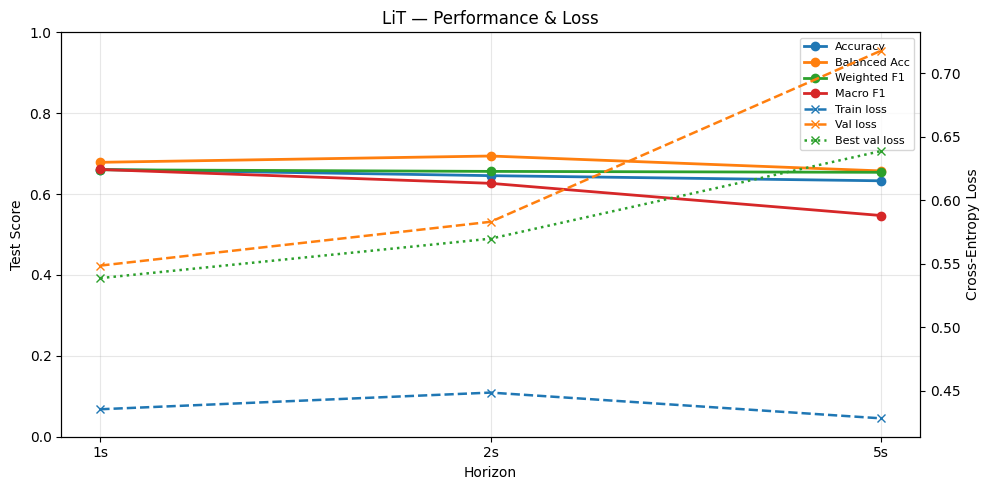

,model,horizon,accuracy,balanced_accuracy,f1_weighted,f1_macro,final_train_loss,final_val_loss,best_val_loss,best_val_epoch
0,LiT,1s,0.6608,0.6786,0.6602,0.6608,0.4356,0.5486,0.5388,14
1,LiT,2s,0.6456,0.6942,0.6561,0.6266,0.4487,0.5831,0.5698,5
2,LiT,5s,0.6329,0.6573,0.6539,0.5470,0.4284,0.7177,0.6387,4


In [ ]:
# Train and evaluate LiT across all horizons
H              = 2 * NUM_LEVELS
INPUT_SHAPE_LIT = (H, T, 2)

lit_results, lit_histories = {}, {}

for k in HORIZONS:
    print(f"\nLiT k={k} ({HORIZON_LABELS[k]})")
    Xtr, ytr = create_lit_dataset(lob_normalised, all_labels[k], train_mask, T, k)
    Xva, yva = create_lit_dataset(lob_normalised, all_labels[k], val_mask,   T, k)
    Xte, yte = create_lit_dataset(lob_normalised, all_labels[k], test_mask,  T, k)
    print(f"Train: {Xtr.shape}  Val: {Xva.shape}  Test: {Xte.shape}")
    cw = get_class_weights(ytr)
    print(f"Class weights: {cw}")

    model = build_lit(input_shape=INPUT_SHAPE_LIT, Ph=H//2, Pw=2)
    model.compile(optimizer=Adam(learning_rate=LR_LIT),
                  loss="categorical_crossentropy", metrics=["accuracy"])
    history = model.fit(Xtr, to_categorical(ytr, 3),
                        batch_size=BATCH_SIZE, epochs=MAX_EPOCHS,
                        validation_data=(Xva, to_categorical(yva, 3)),
                        class_weight=cw, callbacks=make_callbacks(), verbose=2)

    lit_results[k] = {"model": "LiT", **evaluate_model(model, Xte, yte, BATCH_SIZE)}
    lit_histories[k] = history

    print(f"Accuracy: {lit_results[k]['accuracy']:.4f}  |  Macro F1: {lit_results[k]['f1_macro']:.4f}")
    print(classification_report(yte, lit_results[k]['y_pred'], target_names=CLASS_NAMES, digits=4, zero_division=0))

    model.save_weights(f"{CHECKPOINT_DIR}/lit_k{k}.weights.h5")
    if k == 4:
        ft_pretrained_lit = model
    else:
        del model
    del Xtr, ytr, Xva, yva, Xte, yte; tf.keras.backend.clear_session(); gc.collect()

with open(f"{CHECKPOINT_DIR}/lit_results.pkl", "wb") as f:
    pickle.dump({"results": lit_results, "histories": {k: h.history for k, h in lit_histories.items()}}, f)
print("Saved LiT results")

summary_lit = build_results_summary(lit_results, lit_histories)
plot_performance(summary_lit, "LiT — Performance & Loss")
display(summary_lit[DISPLAY_COLS].round(4))


## 9. Model 5 — DeepLOB v2

DeepLOB v2 (referred to as Attentive-DeepLOB in the paper) keeps the same convolutional front end and Inception module as DeepLOB but adds two axial attention layers (Kisiel and Gorse, 2022; Ho et al., 2019) before the LSTM head. Unlike the original DeepLOB, all convolutions use padding='same' so the 10 level positions are preserved throughout the front end. After the Inception block, a 1×1 convolution projects the features to d_model = 32 dimensions, giving a (T, 10, 32) tensor on which the attention layers can operate.

Axial attention factorises 2D self-attention into two cheaper 1D attention operations applied along each axis in turn, reducing computational cost from quadratic in the total number of positions to linear in the product of axis lengths. The first axial layer applies multi-head self-attention (4 heads, d_k = 8, dropout 0.1) across the 10 LOB levels at each timestep, capturing cross-level dependencies such as deep-book liquidity affecting near-mid-price dynamics. The second attends across the time dimension at each level, capturing long-range temporal dependencies that the LSTM may compress away. Each block uses a residual connection followed by layer normalisation. The output is reshaped to (T, 320) and passed to a 64 unit LSTM and softmax head, totalling 130,931 parameters. The design is motivated by the trade-off observed when comparing DeepLOB against LiT. Keeping the convolutional price-volume pairing intact and adding global attention before the LSTM combines the strengths of both architectures.


In [ ]:
# DeepLOB v2 axial attention
class AxialAttentionLevel(layers.Layer):
    def __init__(self, d_model, num_heads=4, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.num_heads = num_heads
        self.attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=max(d_model // num_heads, 1),
            dropout=dropout,
        )
        self.ln = layers.LayerNormalization(epsilon=1e-6)

    def call(self, x, training=False):
        shp = tf.shape(x)
        B, T_, L_, D_ = shp[0], shp[1], shp[2], shp[3]

        x_r = tf.reshape(x, (B * T_, L_, D_))
        attended = self.attn(x_r, x_r, training=training)
        attended = tf.reshape(attended, (B, T_, L_, D_))

        return self.ln(x + attended)

class AxialAttentionTime(layers.Layer):
    def __init__(self, d_model, num_heads=4, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.num_heads = num_heads
        self.attn = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=max(d_model // num_heads, 1),
            dropout=dropout,
        )
        self.ln = layers.LayerNormalization(epsilon=1e-6)

    def call(self, x, training=False):
        x_t = tf.transpose(x, [0, 2, 1, 3])
        shp = tf.shape(x_t)
        B, L_, T_, D_ = shp[0], shp[1], shp[2], shp[3]

        x_r = tf.reshape(x_t, (B * L_, T_, D_))
        attended = self.attn(x_r, x_r, training=training)
        attended = tf.reshape(attended, (B, L_, T_, D_))

        # change back to (B, T, L, D).
        attended = tf.transpose(attended, [0, 2, 1, 3])
        return self.ln(x + attended)

def build_deeplob_v2(T=100, num_features=40, num_classes=3,
                     leaky_alpha=0.01, d_model=32, num_heads=4):
    NUM_LEVELS = 10
    inputs = layers.Input(shape=(T, num_features, 1))

    # Block 1: pair price/volume per level
    x = layers.Conv2D(16, (1, 2), strides=(1, 2), padding='same')(inputs)
    x = layers.LeakyReLU(alpha=leaky_alpha)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(16, (4, 1), padding='same')(x)
    x = layers.LeakyReLU(alpha=leaky_alpha)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(16, (4, 1), padding='same')(x)
    x = layers.LeakyReLU(alpha=leaky_alpha)(x)
    x = layers.BatchNormalization()(x)

    # Block 2: pair ask/bid per level
    x = layers.Conv2D(16, (1, 2), strides=(1, 2), padding='same')(x)
    x = layers.LeakyReLU(alpha=leaky_alpha)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(16, (4, 1), padding='same')(x)
    x = layers.LeakyReLU(alpha=leaky_alpha)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(16, (4, 1), padding='same')(x)
    x = layers.LeakyReLU(alpha=leaky_alpha)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(16, (1, 10), padding='same')(x)
    x = layers.LeakyReLU(alpha=leaky_alpha)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(16, (4, 1), padding='same')(x)
    x = layers.LeakyReLU(alpha=leaky_alpha)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(16, (4, 1), padding='same')(x)
    x = layers.LeakyReLU(alpha=leaky_alpha)(x)
    x = layers.BatchNormalization()(x)

    # Inception block
    b1 = layers.Conv2D(32, (1, 1), padding='same')(x)
    b1 = layers.LeakyReLU(alpha=leaky_alpha)(b1)
    b1 = layers.BatchNormalization()(b1)
    b1 = layers.Conv2D(32, (3, 1), padding='same')(b1)
    b1 = layers.LeakyReLU(alpha=leaky_alpha)(b1)
    b1 = layers.BatchNormalization()(b1)

    b2 = layers.Conv2D(32, (1, 1), padding='same')(x)
    b2 = layers.LeakyReLU(alpha=leaky_alpha)(b2)
    b2 = layers.BatchNormalization()(b2)
    b2 = layers.Conv2D(32, (5, 1), padding='same')(b2)
    b2 = layers.LeakyReLU(alpha=leaky_alpha)(b2)
    b2 = layers.BatchNormalization()(b2)

    b3 = layers.MaxPooling2D((3, 1), strides=(1, 1), padding='same')(x)
    b3 = layers.Conv2D(32, (1, 1), padding='same')(b3)
    b3 = layers.LeakyReLU(alpha=leaky_alpha)(b3)
    b3 = layers.BatchNormalization()(b3)

    x = layers.Concatenate(axis=-1)([b1, b2, b3])

    x = layers.Conv2D(d_model, (1, 1), padding='same')(x)

    x = AxialAttentionLevel(d_model, num_heads, name='axial_level')(x)
    # attention along the time axis at each level
    x = AxialAttentionTime(d_model, num_heads, name='axial_time')(x)

    x = layers.Reshape((T, NUM_LEVELS * d_model))(x)

    # LSTM head
    x = layers.LSTM(64)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name='DeepLOB_v2')

_tmp = build_deeplob_v2(T=T, num_features=NUM_FEATURES, num_classes=3)
_tmp.summary(line_length=110)
del _tmp
tf.keras.backend.clear_session()
gc.collect()


Model: "DeepLOB_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                   ┃ Output Shape              ┃          Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)       │ (None, 50, 40, 1)         │                0 │ -                          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ conv2d (Conv2D)                │ (None, 50, 20, 16)        │               48 │ input_layer[0][0]          │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ leaky_re_lu (LeakyReLU)        │ (None, 50, 20, 16)        │                0 │ conv2d[0][0]               │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ batch_normalization            │ (None, 50, 20, 16)        │               64 │ leaky_re_lu[0][0]          │
│ (BatchNormalization)           │                           │                  │                            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)              │ (None, 50, 20, 16)        │            1,040 │ batch_normalization[0][0]  │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ leaky_re_lu_1 (LeakyReLU)      │ (None, 50, 20, 16)        │                0 │ conv2d_1[0][0]             │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ batch_normalization_1          │ (None, 50, 20, 16)        │               64 │ leaky_re_lu_1[0][0]        │
│ (BatchNormalization)           │                           │                  │                            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)              │ (None, 50, 20, 16)        │            1,040 │ batch_normalization_1[0][… │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ leaky_re_lu_2 (LeakyReLU)      │ (None, 50, 20, 16)        │                0 │ conv2d_2[0][0]             │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ batch_normalization_2          │ (None, 50, 20, 16)        │               64 │ leaky_re_lu_2[0][0]        │
│ (BatchNormalization)           │                           │                  │                            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)              │ (None, 50, 10, 16)        │              528 │ batch_normalization_2[0][… │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ leaky_re_lu_3 (LeakyReLU)      │ (None, 50, 10, 16)        │                0 │ conv2d_3[0][0]             │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ batch_normalization_3          │ (None, 50, 10, 16)        │               64 │ leaky_re_lu_3[0][0]        │
│ (BatchNormalization)           │                           │                  │                            │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)              │ (None, 50, 10, 16)        │            1,040 │ batch_normalization_3[0][… │
├────────────────────────────────┼───────────────────────────┼──────────────────┼────────────────────────────┤
│ leaky_re_lu_4 (LeakyReLU)      │ (None, 50, 10, 16)        │                0 │ conv2d_4[0][0]             │
├───

 Total params: 130,931 (511.45 KB)

 Trainable params: 130,323 (509.07 KB)

 Non-trainable params: 608 (2.38 KB)

0


DeepLOB v2 k=4 (1s)
Train: (1033634, 50, 40, 1)  Val: (344575, 50, 40, 1)  Test: (344563, 50, 40, 1)
Class weights: {0: 1.8407327071913722, 1: 0.5185871973983192, 2: 1.8924266974249124}
Epoch 1/50
4038/4038 - 231s - 57ms/step - accuracy: 0.7924 - loss: 0.5133 - val_accuracy: 0.7718 - val_loss: 0.5502 - learning_rate: 5.0000e-04
Epoch 2/50
4038/4038 - 213s - 53ms/step - accuracy: 0.8150 - loss: 0.4701 - val_accuracy: 0.7777 - val_loss: 0.5356 - learning_rate: 5.0000e-04
Epoch 3/50
4038/4038 - 214s - 53ms/step - accuracy: 0.8209 - loss: 0.4576 - val_accuracy: 0.7799 - val_loss: 0.5327 - learning_rate: 5.0000e-04
Epoch 4/50
4038/4038 - 213s - 53ms/step - accuracy: 0.8249 - loss: 0.4469 - val_accuracy: 0.7738 - val_loss: 0.5401 - learning_rate: 5.0000e-04
Epoch 5/50
4038/4038 - 213s - 53ms/step - accuracy: 0.8291 - loss: 0.4349 - val_accuracy: 0.7645 - val_loss: 0.5557 - learning_rate: 5.0000e-04
Epoch 6/50
4038/4038 - 213s - 53ms/step - accuracy: 0.8329 - loss: 0.4210 - val_accuracy: 0.7

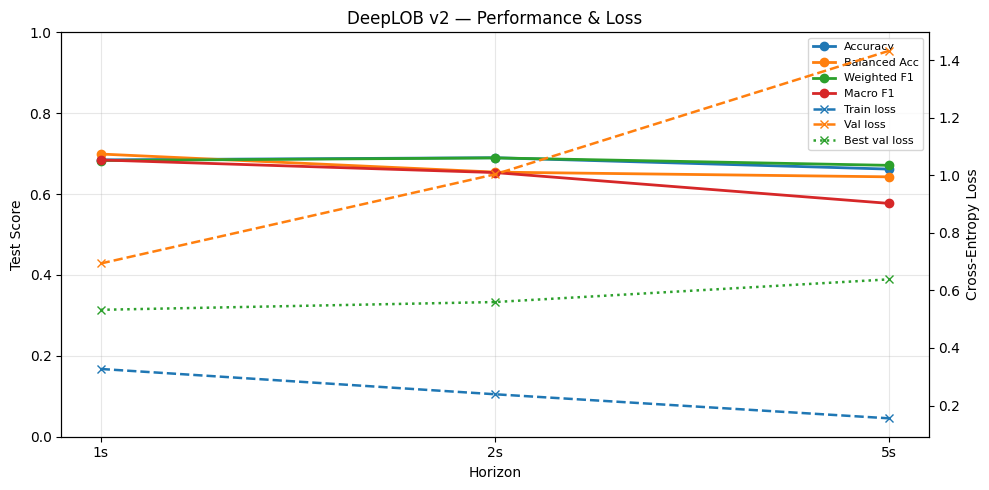

,model,horizon,accuracy,balanced_accuracy,f1_weighted,f1_macro,final_train_loss,final_val_loss,best_val_loss,best_val_epoch
0,DeepLOB v2,1s,0.6846,0.6991,0.6830,0.6845,0.3270,0.6937,0.5327,3
1,DeepLOB v2,2s,0.6899,0.6544,0.6895,0.6532,0.2391,1.0037,0.5597,2
2,DeepLOB v2,5s,0.6618,0.6427,0.6711,0.5769,0.1554,1.4335,0.6386,1


In [ ]:
# Train and evaluate DeepLOB v2 across all horizons
deeplob_v2_results, deeplob_v2_histories = {}, {}

for k in HORIZONS:
    print(f"\nDeepLOB v2 k={k} ({HORIZON_LABELS[k]})")
    Xtr, ytr = create_deeplob_dataset(lob_normalised, all_labels[k], train_mask, T, k)
    Xva, yva = create_deeplob_dataset(lob_normalised, all_labels[k], val_mask,   T, k)
    Xte, yte = create_deeplob_dataset(lob_normalised, all_labels[k], test_mask,  T, k)
    print(f"Train: {Xtr.shape}  Val: {Xva.shape}  Test: {Xte.shape}")
    cw = get_class_weights(ytr)
    print(f"Class weights: {cw}")

    model = build_deeplob_v2(T=T, num_features=NUM_FEATURES, num_classes=3)
    model.compile(optimizer=Adam(learning_rate=LR_DLV2),
                  loss="categorical_crossentropy", metrics=["accuracy"])
    history = model.fit(Xtr, to_categorical(ytr, 3),
                        batch_size=BATCH_SIZE, epochs=MAX_EPOCHS,
                        validation_data=(Xva, to_categorical(yva, 3)),
                        class_weight=cw, callbacks=make_callbacks(), verbose=2)

    deeplob_v2_results[k] = {"model": "DeepLOB v2", **evaluate_model(model, Xte, yte, BATCH_SIZE)}
    deeplob_v2_histories[k] = history

    print(f"Accuracy: {deeplob_v2_results[k]['accuracy']:.4f}  |  Macro F1: {deeplob_v2_results[k]['f1_macro']:.4f}")
    print(classification_report(yte, deeplob_v2_results[k]['y_pred'], target_names=CLASS_NAMES, digits=4, zero_division=0))

    model.save_weights(f"{CHECKPOINT_DIR}/dlv2_k{k}.weights.h5")
    if k == 4:
        ft_pretrained_dlv2 = model
    else:
        del model
    del Xtr, ytr, Xva, yva, Xte, yte; tf.keras.backend.clear_session(); gc.collect()

with open(f"{CHECKPOINT_DIR}/deeplob_v2_results.pkl", "wb") as f:
    pickle.dump({"results": deeplob_v2_results, "histories": {k: h.history for k, h in deeplob_v2_histories.items()}}, f)

summary_dlv2 = build_results_summary(deeplob_v2_results, deeplob_v2_histories)
plot_performance(summary_dlv2, "DeepLOB v2 — Performance & Loss")
display(summary_dlv2[DISPLAY_COLS].round(4))


## 10. Comparative Figures

All five models are compared across horizons. Figures 1–3 cover aggregate metrics, Figure 4 shows per-class F1, Figure 5 shows normalised confusion matrices, Figures 6–7 plot training dynamics and Figure 8 outputs overfitting diagnostics.


In [ ]:
# put all results in one DataFrame
HORIZON_ORDER = ["1s", "2s", "5s"]
MODEL_ORDER   = ["OFI Linear", "Plain LSTM", "LiT", "DeepLOB", "DeepLOB v2"]

all_results = pd.DataFrame([
    *[{**ofi_results[k],         "horizon": HORIZON_LABELS[k]} for k in HORIZONS],
    *[{**lstm_results[k],        "horizon": HORIZON_LABELS[k]} for k in HORIZONS],
    *[{**lit_results[k],         "horizon": HORIZON_LABELS[k]} for k in HORIZONS],
    *[{**deeplob_results[k],     "horizon": HORIZON_LABELS[k]} for k in HORIZONS],
    *[{**deeplob_v2_results[k],  "horizon": HORIZON_LABELS[k]} for k in HORIZONS],
])
all_results["horizon"] = pd.Categorical(all_results["horizon"], categories=HORIZON_ORDER, ordered=True)
all_results["model"]   = pd.Categorical(all_results["model"],   categories=MODEL_ORDER,   ordered=True)
all_results = all_results.sort_values(["horizon", "model"])

display_cols = ["model","horizon","accuracy","balanced_accuracy","f1_weighted","f1_macro",
                "precision_weighted","recall_weighted"]
display(all_results[display_cols].round(4))


,model,horizon,accuracy,balanced_accuracy,f1_weighted,f1_macro,precision_weighted,recall_weighted
0,OFI Linear,1s,0.4304,0.4439,0.4328,0.4310,0.4712,0.4304
3,Plain LSTM,1s,0.6390,0.6581,0.6378,0.6378,0.6798,0.6390
6,LiT,1s,0.6608,0.6786,0.6602,0.6608,0.6883,0.6608
9,DeepLOB,1s,0.6408,0.6648,0.6391,0.6403,0.6884,0.6408
12,DeepLOB v2,1s,0.6846,0.6991,0.6830,0.6845,0.7013,0.6846
1,OFI Linear,2s,0.4102,0.4644,0.4412,0.4025,0.5532,0.4102
4,Plain LSTM,2s,0.5841,0.6521,0.6047,0.5687,0.6875,0.5841
7,LiT,2s,0.6456,0.6942,0.6561,0.6266,0.7022,0.6456
10,DeepLOB,2s,0.6973,0.6874,0.6995,0.6717,0.7041,0.6973
13,DeepLOB v2,2s,0.6899,0.6544,0.6895,0.6532,0.6925,0.6899


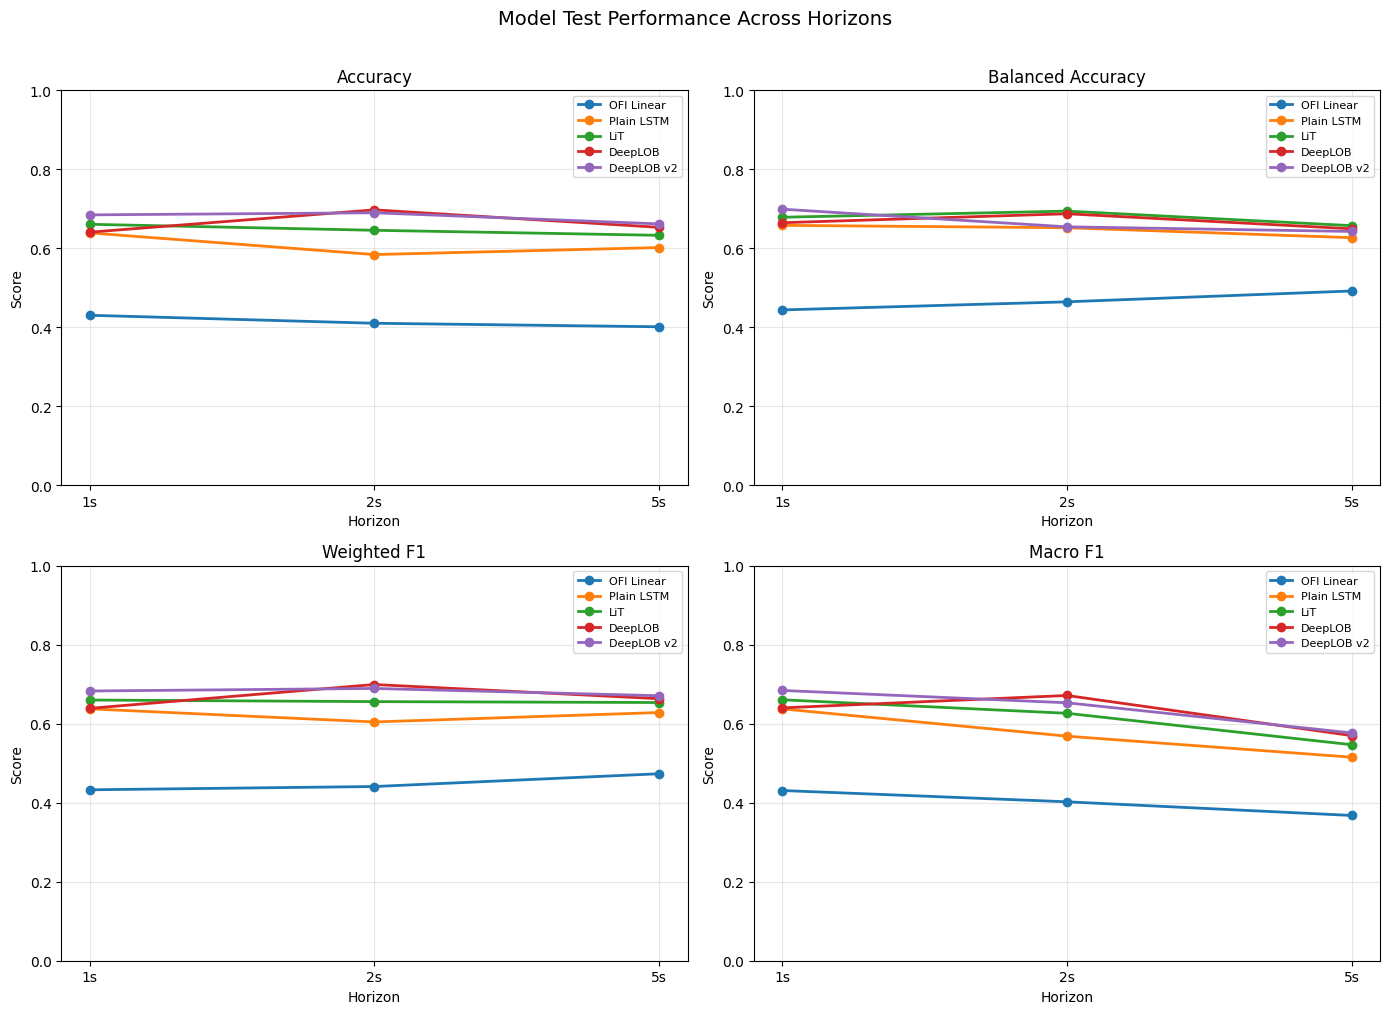

In [ ]:
# plots
metrics = [("accuracy","Accuracy"),("balanced_accuracy","Balanced Accuracy"),
           ("f1_weighted","Weighted F1"),("f1_macro","Macro F1")]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (metric, name) in zip(axes.flatten(), metrics):
    for mn in MODEL_ORDER:
        d = all_results[all_results["model"]==mn].sort_values("horizon")
        ax.plot(d["horizon"].astype(str), d[metric], marker="o", linewidth=2, label=mn)
    ax.set_title(name); ax.set_xlabel("Horizon"); ax.set_ylabel("Score")
    ax.set_ylim(0, 1); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.suptitle("Model Test Performance Across Horizons", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


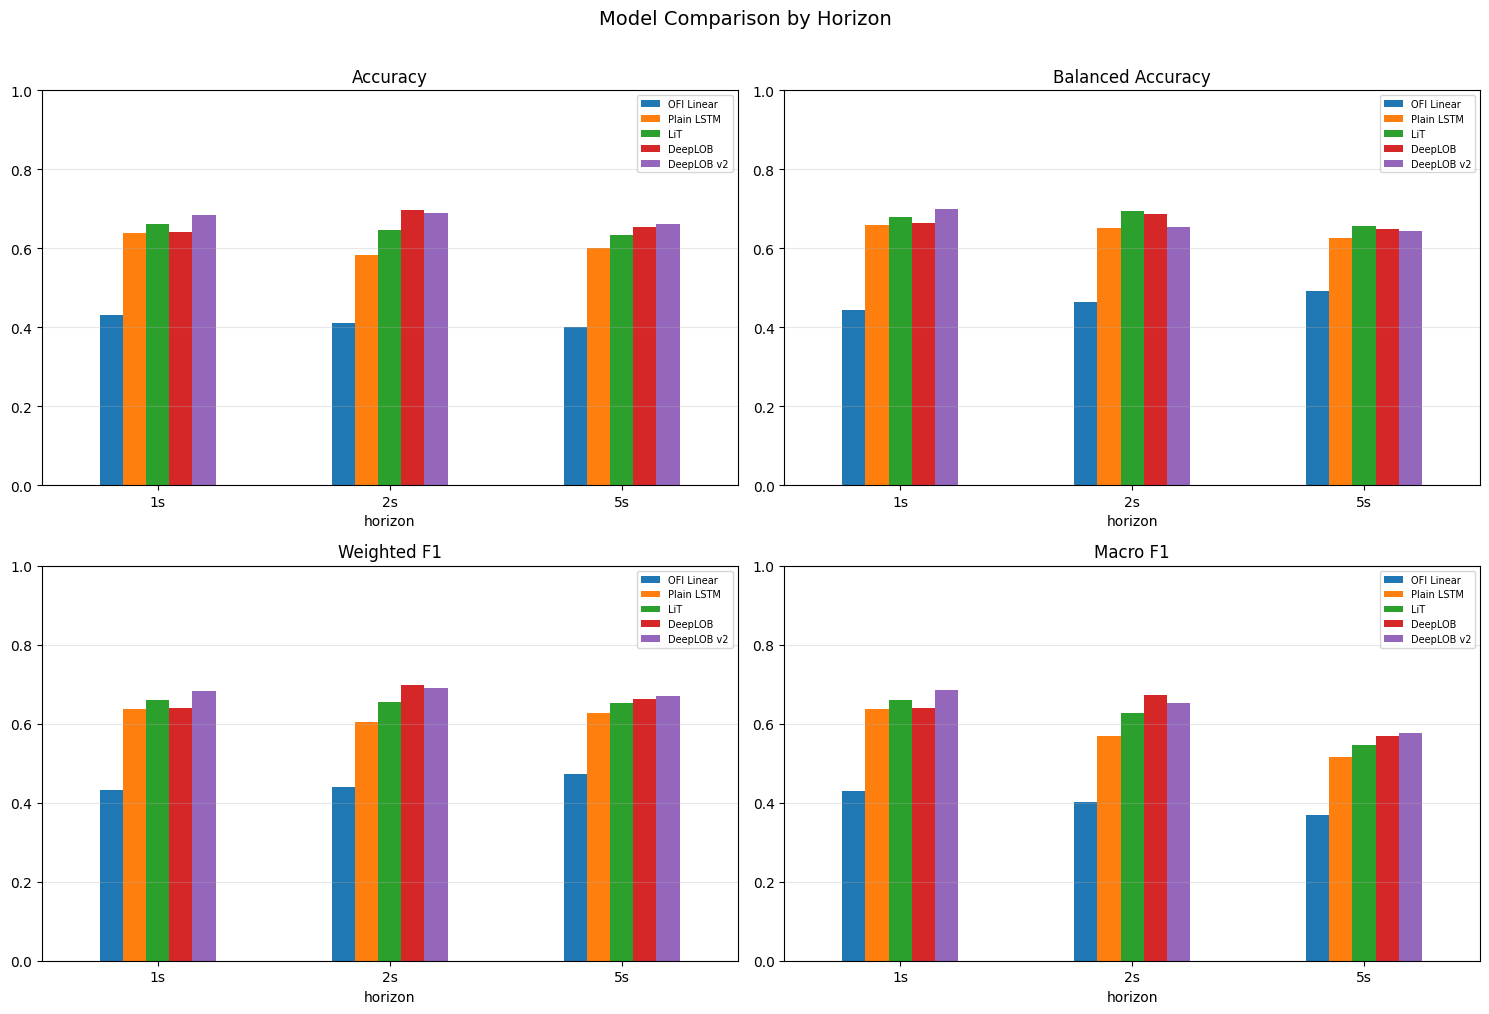

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, (metric, name) in zip(axes.flatten(), metrics):
    pivot = all_results.pivot(index="horizon", columns="model", values=metric).loc[HORIZON_ORDER]
    pivot.plot(kind="bar", ax=ax, rot=0)
    ax.set_title(name); ax.set_ylim(0, 1); ax.grid(axis="y", alpha=0.3); ax.legend(fontsize=7)
plt.suptitle("Model Comparison by Horizon", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


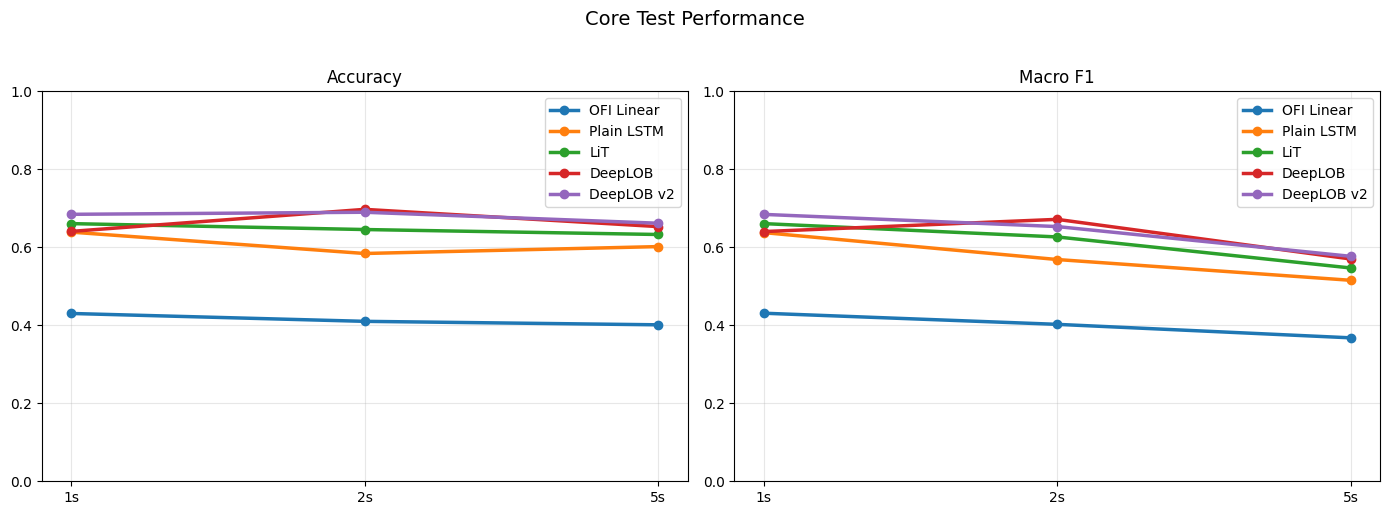

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (metric, name) in zip(axes, [("accuracy","Accuracy"),("f1_macro","Macro F1")]):
    for mn in MODEL_ORDER:
        d = all_results[all_results["model"]==mn].sort_values("horizon")
        ax.plot(d["horizon"].astype(str), d[metric], marker="o", linewidth=2.5, label=mn)
    ax.set_title(name); ax.set_ylim(0, 1); ax.grid(alpha=0.3); ax.legend()
plt.suptitle("Core Test Performance", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()


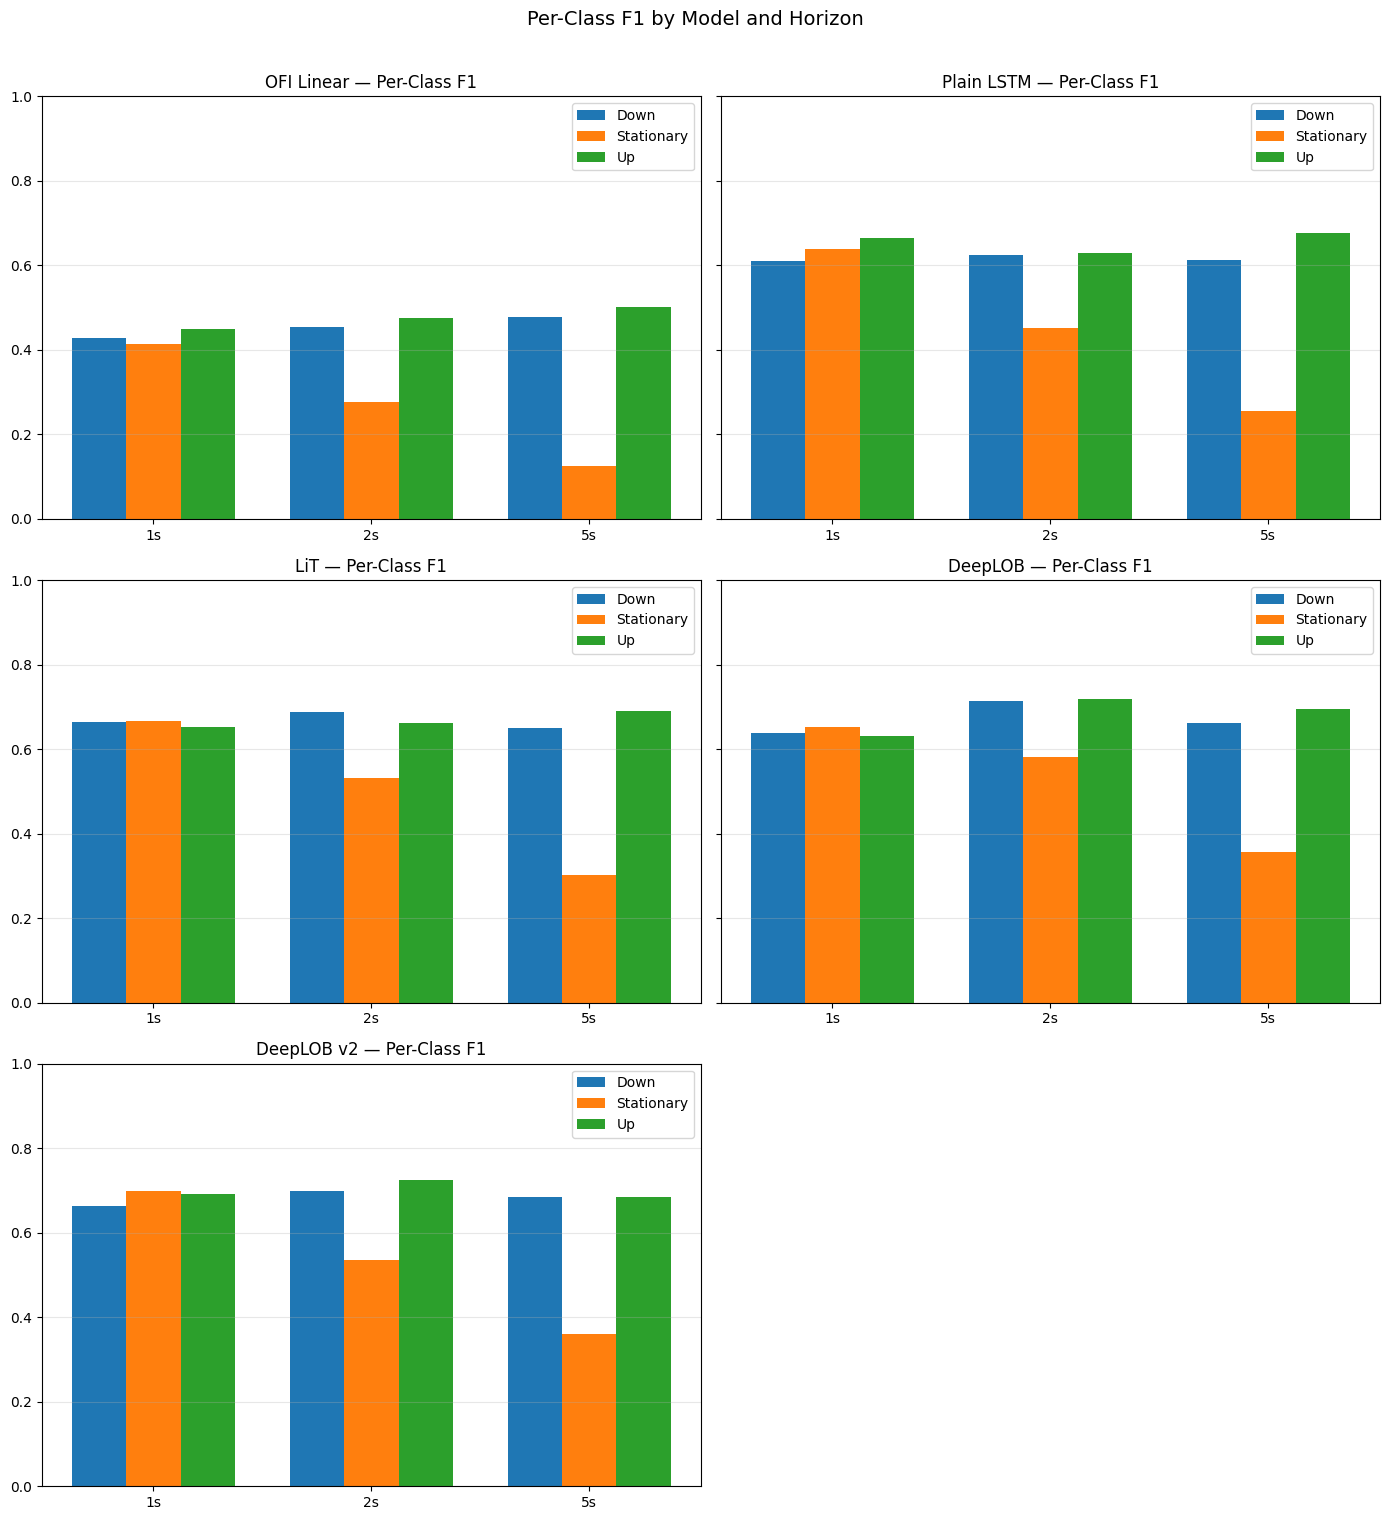

In [ ]:
model_preds = {
    "OFI Linear": {HORIZON_LABELS[k]: (ofi_results[k]["y_test"],        ofi_results[k]["y_pred"])        for k in HORIZONS},
    "Plain LSTM": {HORIZON_LABELS[k]: (lstm_results[k]["y_test"],        lstm_results[k]["y_pred"])        for k in HORIZONS},
    "LiT":        {HORIZON_LABELS[k]: (lit_results[k]["y_test"],         lit_results[k]["y_pred"])         for k in HORIZONS},
    "DeepLOB":    {HORIZON_LABELS[k]: (deeplob_results[k]["y_test"],     deeplob_results[k]["y_pred"])     for k in HORIZONS},
    "DeepLOB v2": {HORIZON_LABELS[k]: (deeplob_v2_results[k]["y_test"],  deeplob_v2_results[k]["y_pred"])  for k in HORIZONS},
}
n_models = len(model_preds)
fig, axes = plt.subplots((n_models+1)//2, 2, figsize=(14, 5*((n_models+1)//2)), sharey=True)
for ax, (mn, preds) in zip(axes.flatten(), model_preds.items()):
    x = np.arange(len(HORIZON_ORDER)); w = 0.25
    for ci, cn in enumerate(CLASS_NAMES):
        vals = [f1_score(preds[h][0], preds[h][1], labels=[0,1,2], average=None, zero_division=0)[ci]
                for h in HORIZON_ORDER]
        ax.bar(x + ci*w, vals, w, label=cn)
    ax.set_title(f"{mn} — Per-Class F1"); ax.set_xticks(x+w); ax.set_xticklabels(HORIZON_ORDER)
    ax.set_ylim(0, 1); ax.grid(axis="y", alpha=0.3); ax.legend()
for ax in axes.flatten()[n_models:]: ax.axis("off")
plt.suptitle("Per-Class F1 by Model and Horizon", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


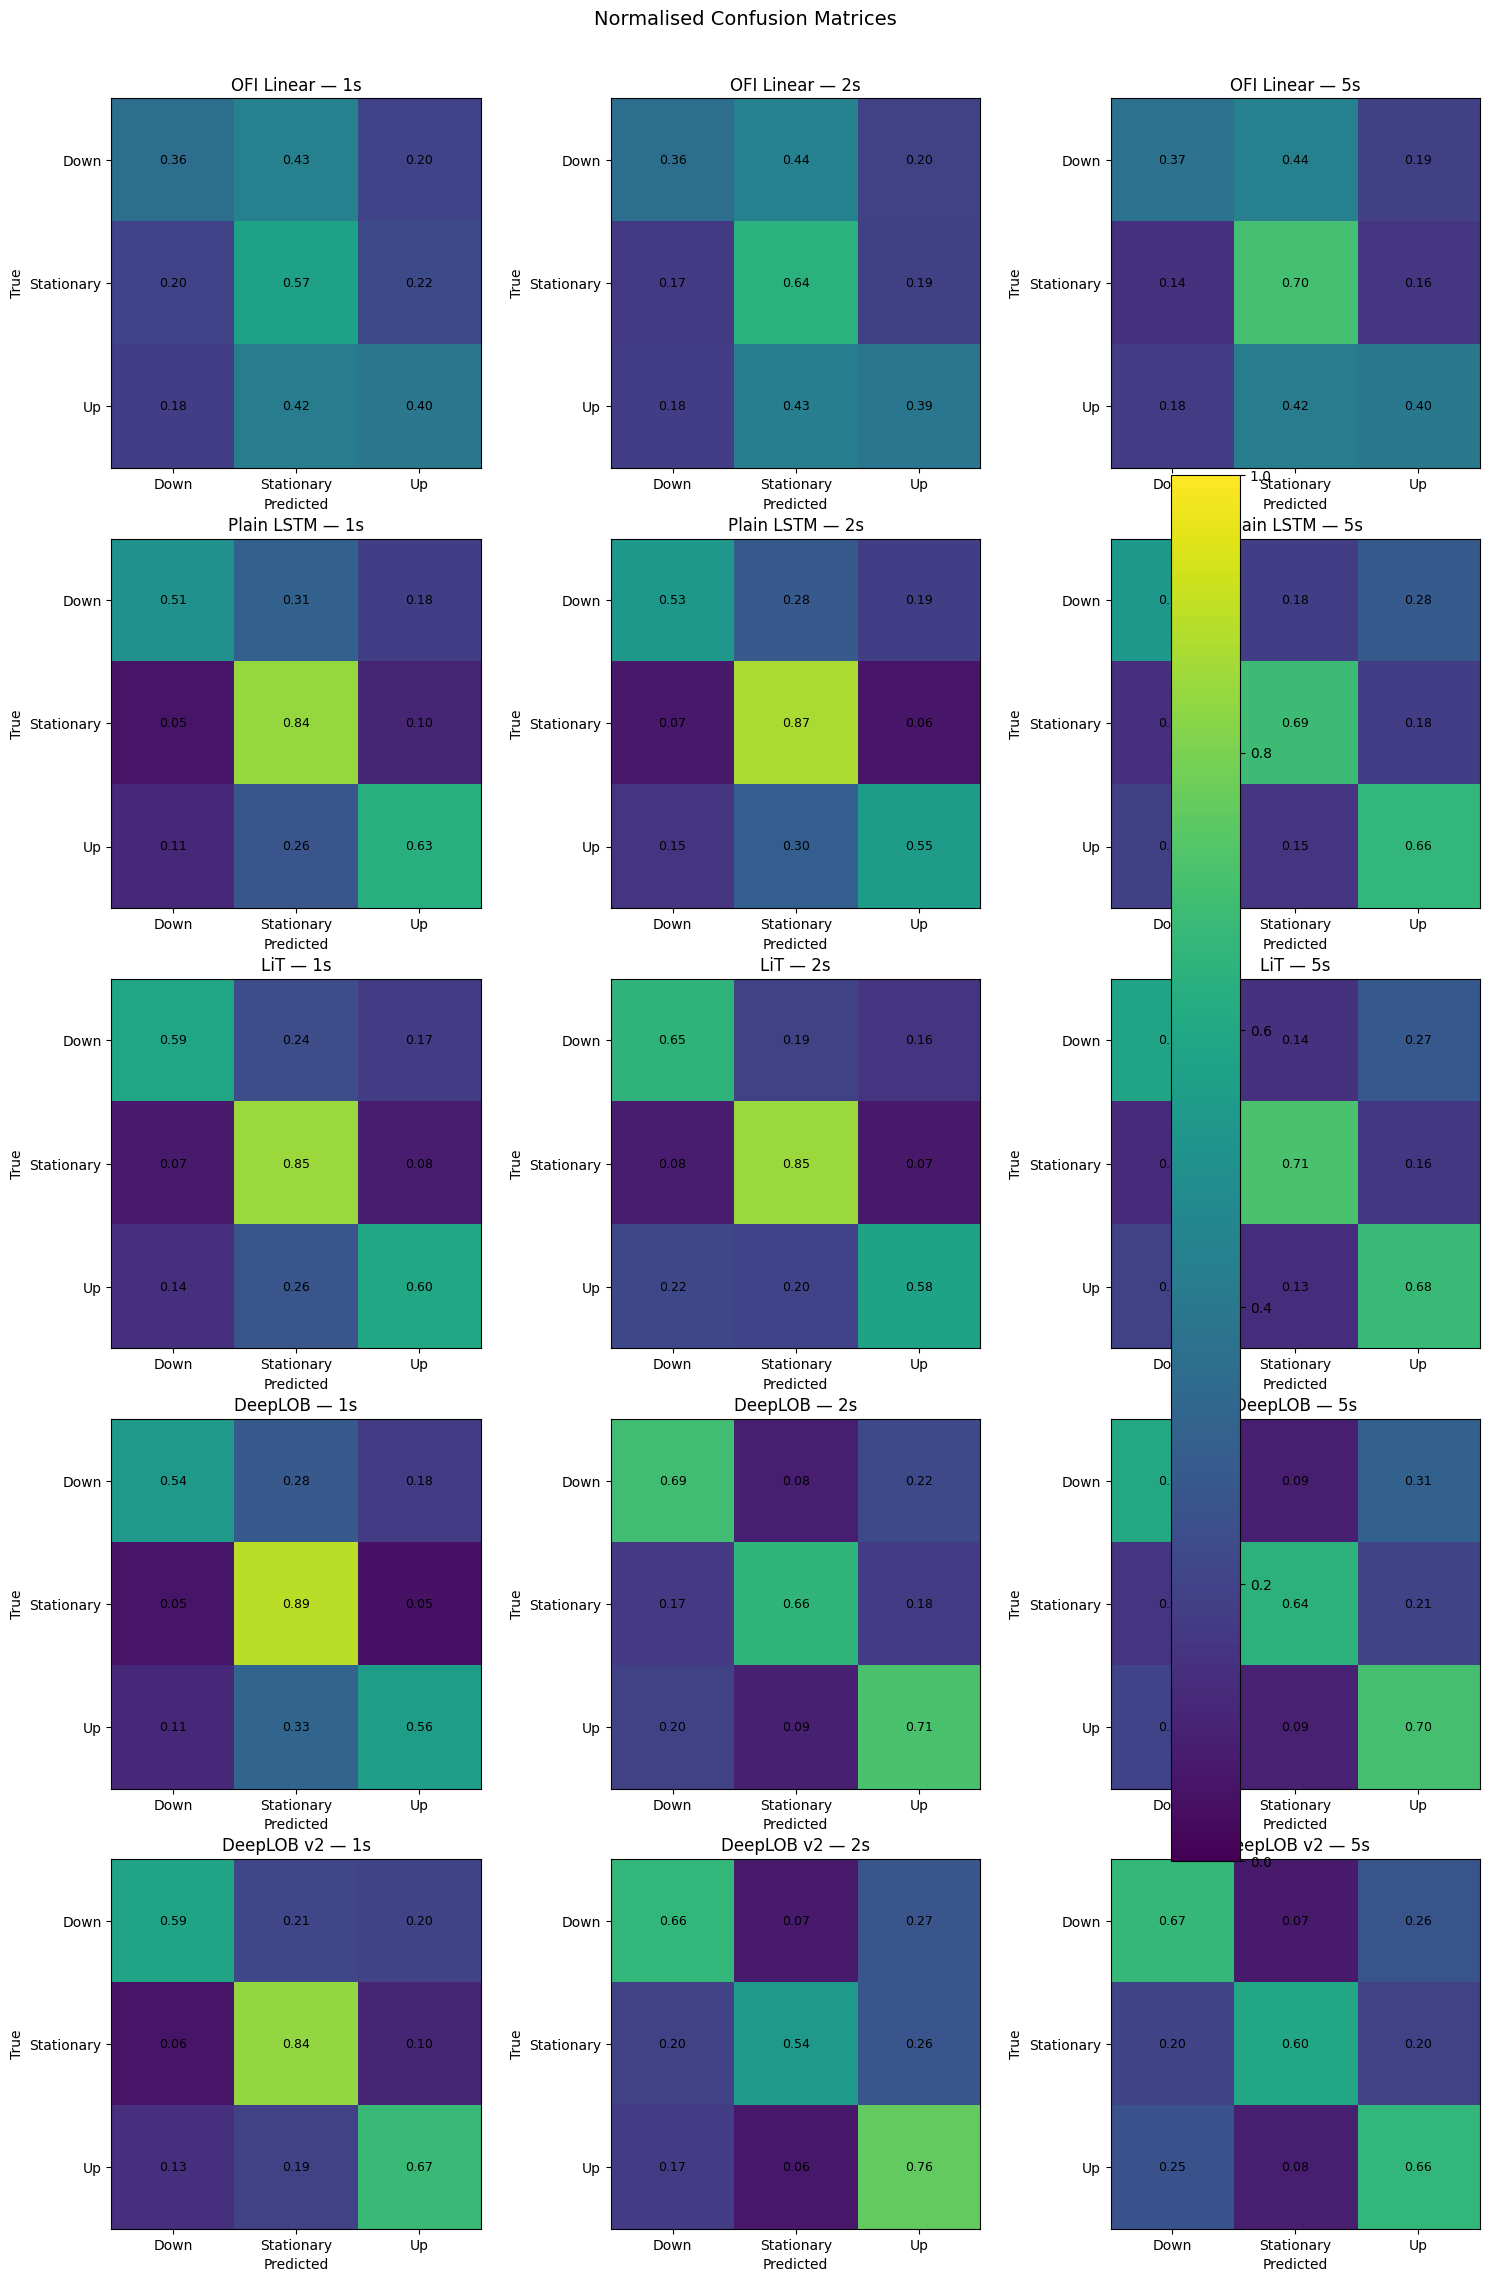

In [ ]:
fig, axes = plt.subplots(n_models, len(HORIZON_ORDER),
                          figsize=(5*len(HORIZON_ORDER), 4.5*n_models))
for ri, mn in enumerate(model_preds):
    for ci, h in enumerate(HORIZON_ORDER):
        ax = axes[ri, ci]
        yt, yp = model_preds[mn][h]
        cm = confusion_matrix(yt, yp).astype(float)
        cm = np.nan_to_num(cm / cm.sum(axis=1, keepdims=True))
        im = ax.imshow(cm, vmin=0, vmax=1)
        for i in range(3):
            for j in range(3):
                ax.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center", fontsize=9)
        ax.set_title(f"{mn} — {h}"); ax.set_xticks(range(3)); ax.set_yticks(range(3))
        ax.set_xticklabels(CLASS_NAMES); ax.set_yticklabels(CLASS_NAMES)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.suptitle("Normalised Confusion Matrices", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


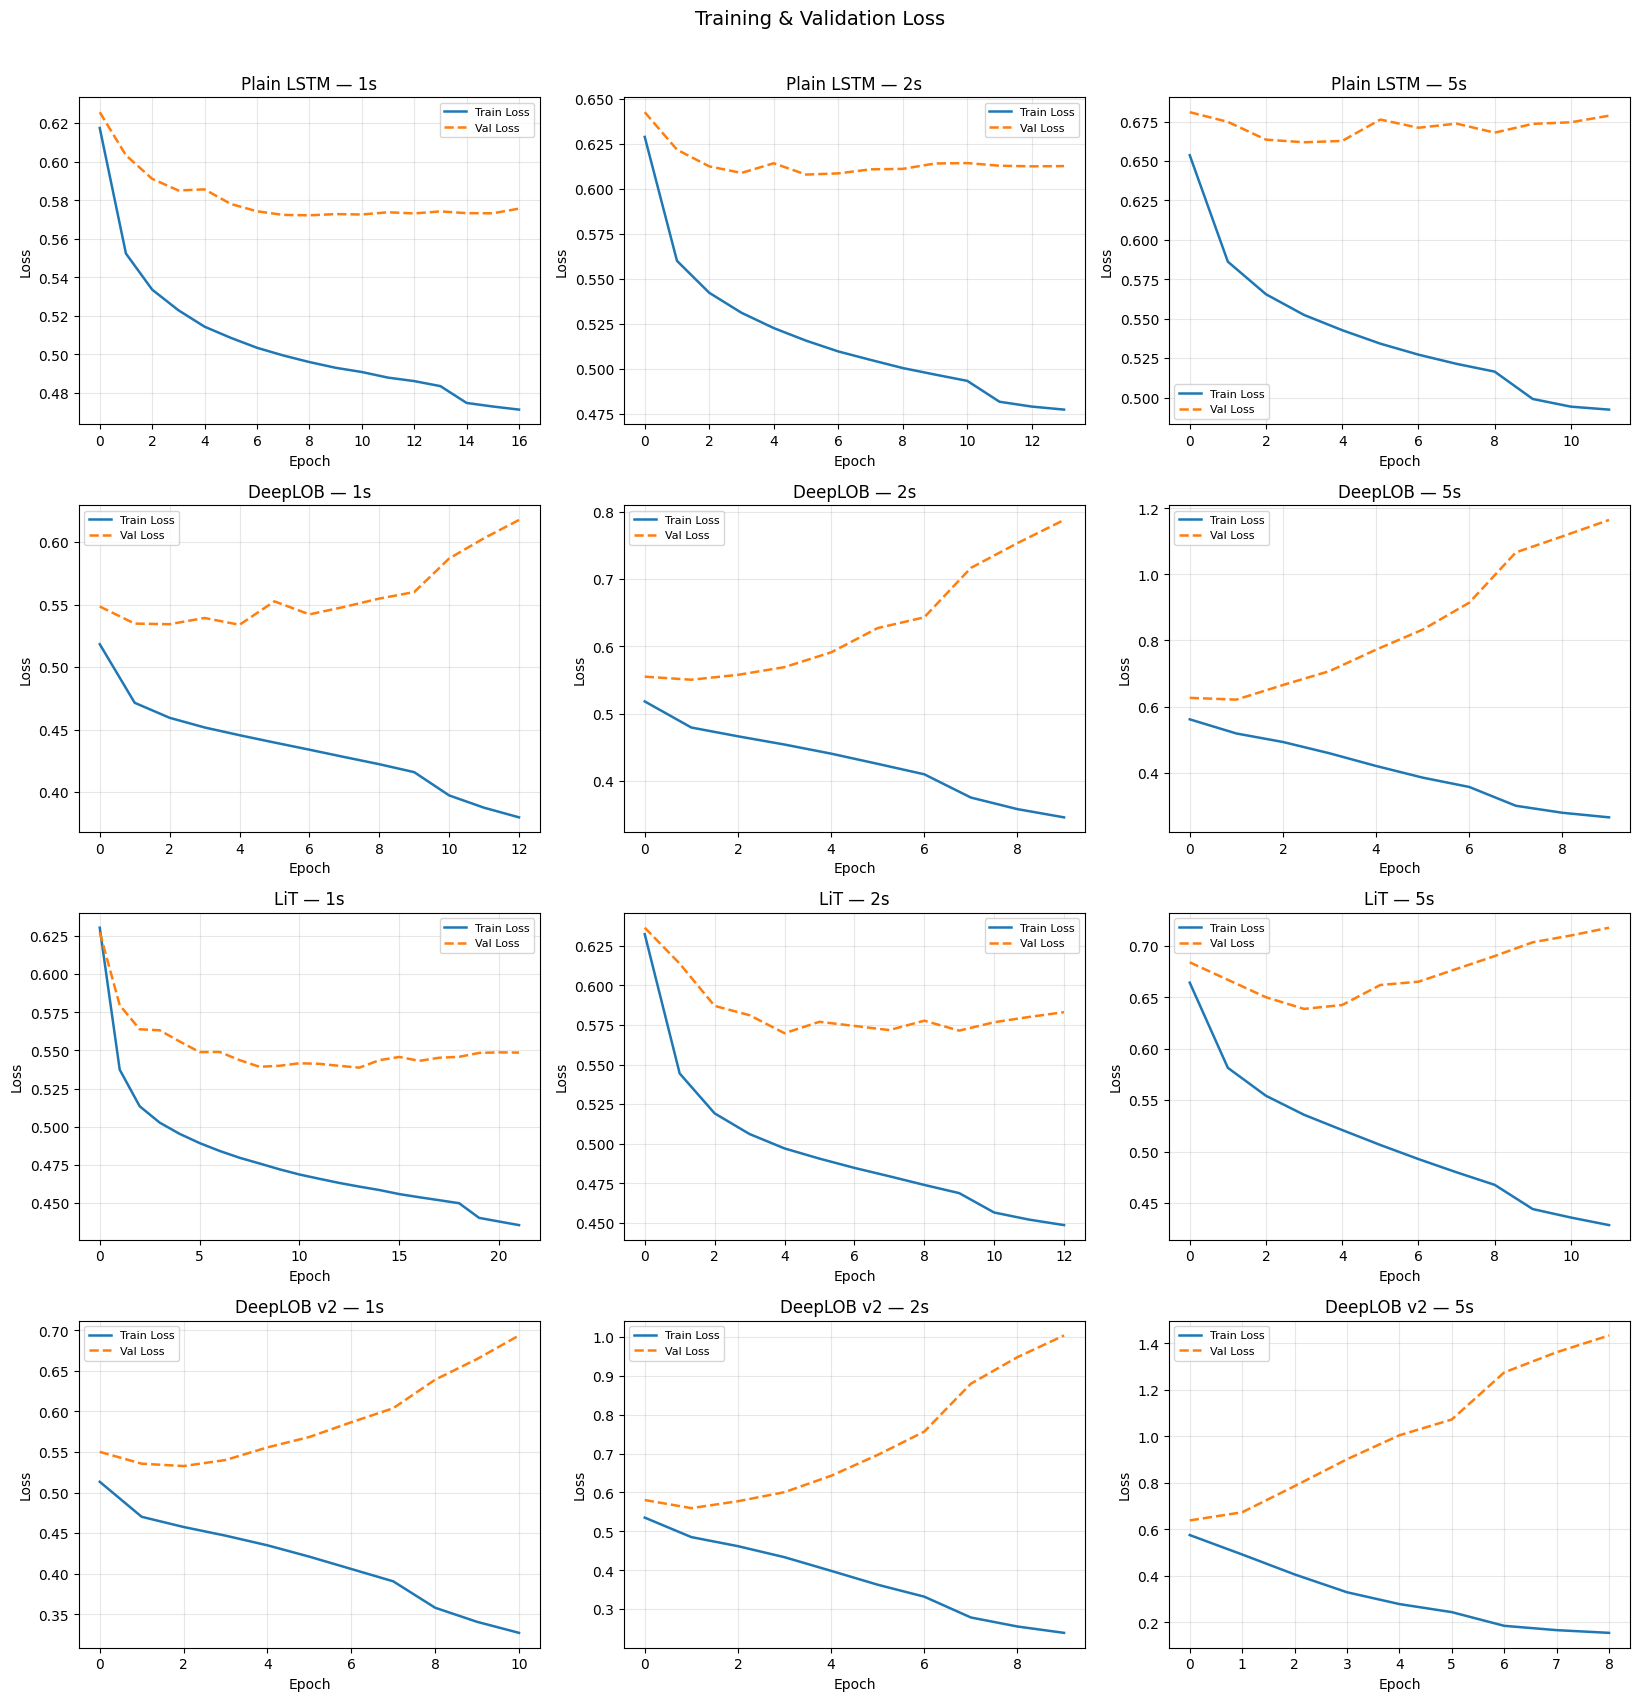

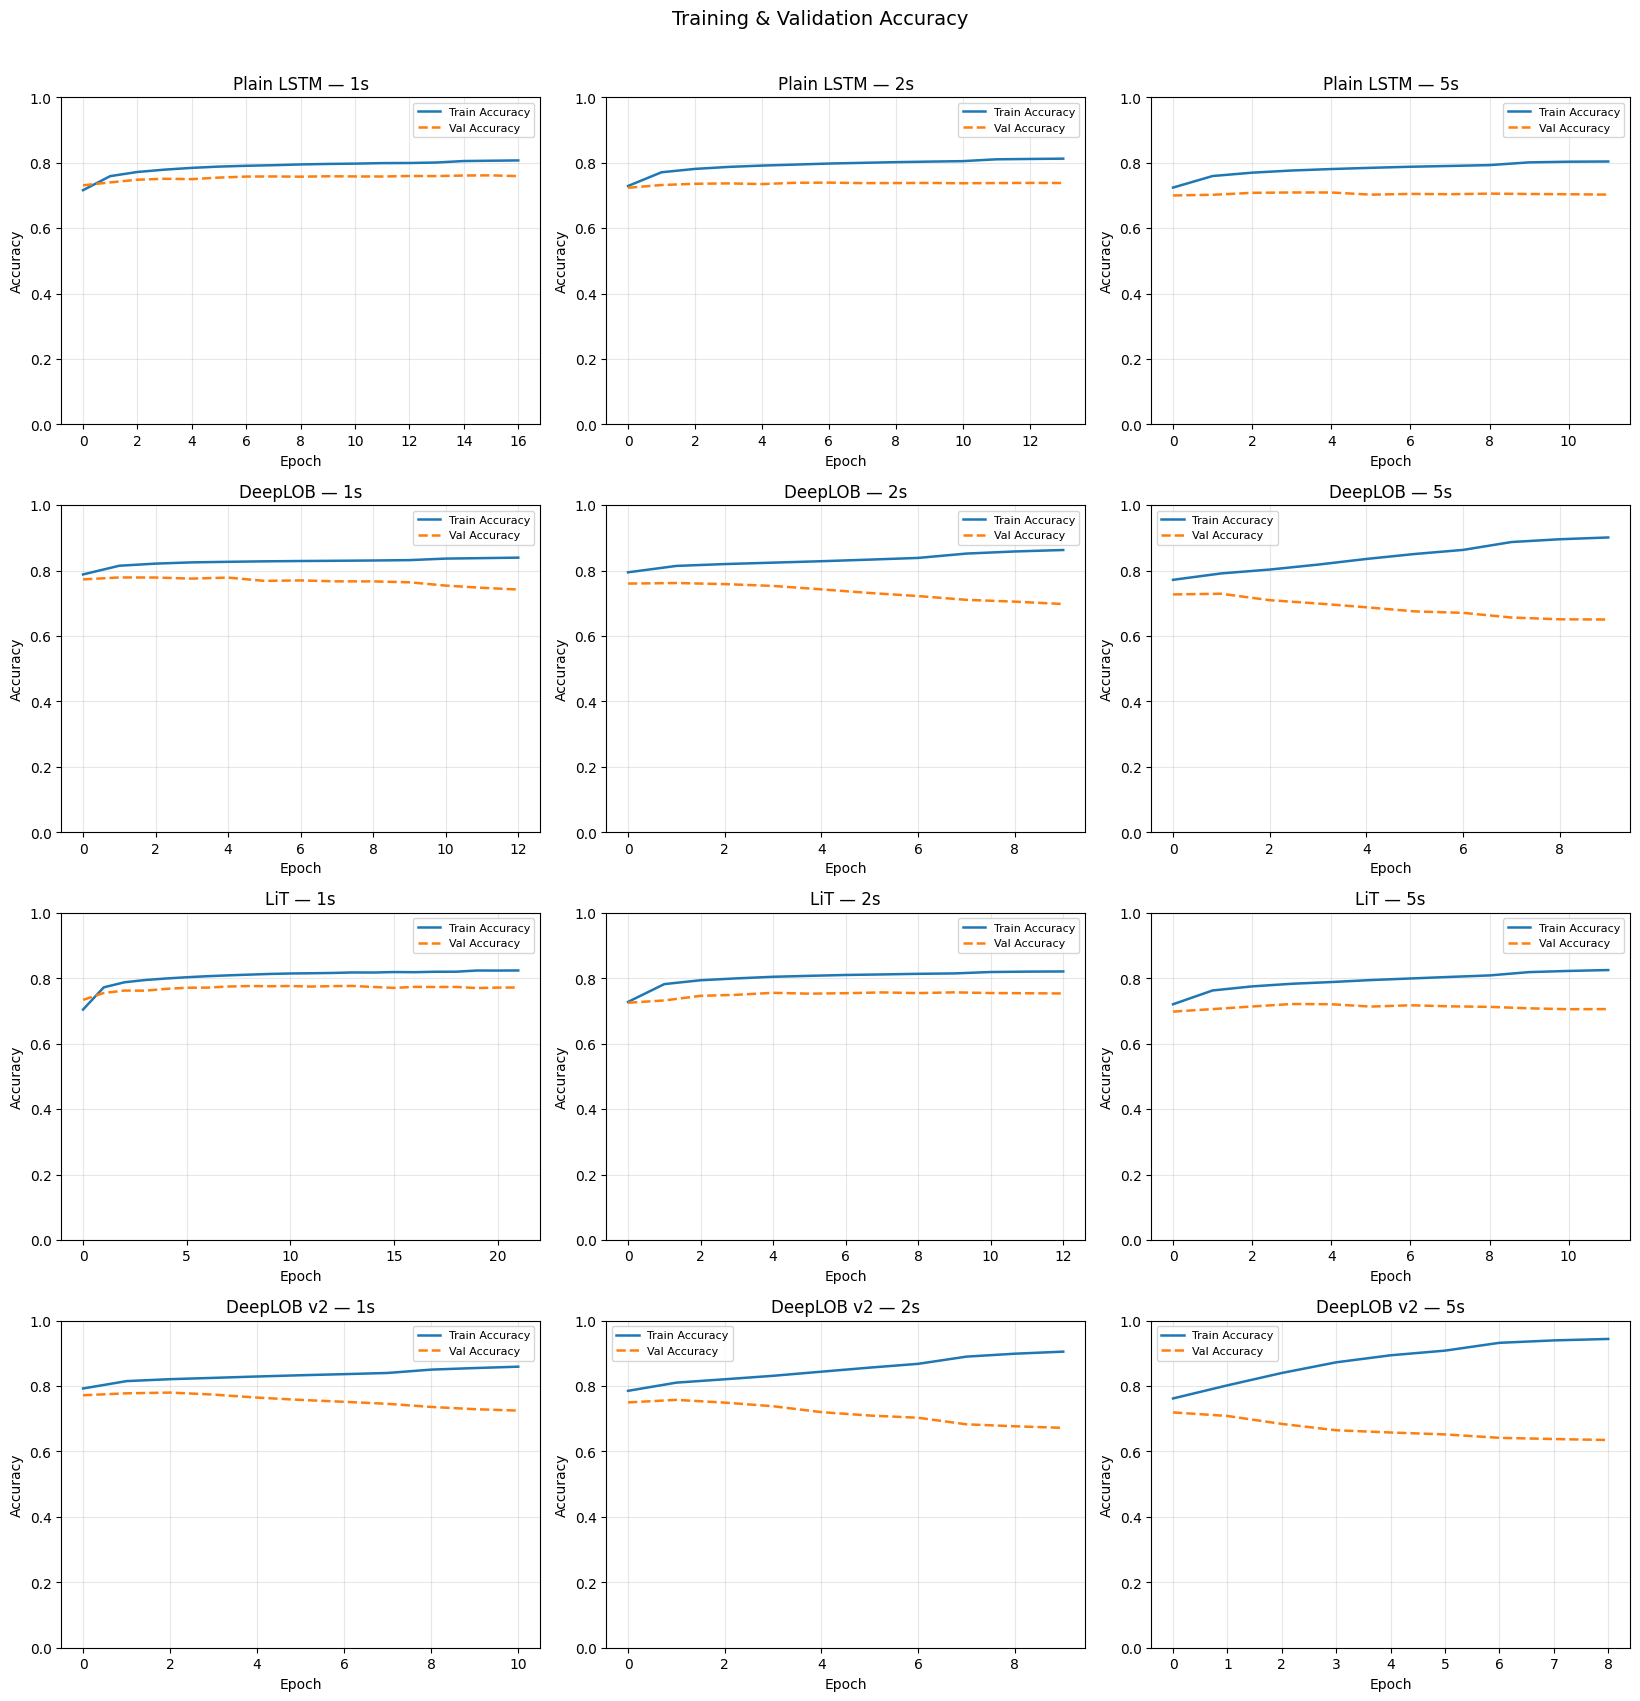

In [ ]:
history_dicts = {
    "Plain LSTM": {HORIZON_LABELS[k]: lstm_histories[k]        for k in HORIZONS},
    "DeepLOB":    {HORIZON_LABELS[k]: deeplob_histories[k]     for k in HORIZONS},
    "LiT":        {HORIZON_LABELS[k]: lit_histories[k]         for k in HORIZONS},
    "DeepLOB v2": {HORIZON_LABELS[k]: deeplob_v2_histories[k]  for k in HORIZONS},
}
n_deep = len(history_dicts)

for metric_key, metric_label, ylim in [
    ("loss",     "Loss",     None),
    ("accuracy", "Accuracy", (0, 1)),
]:
    fig, axes = plt.subplots(n_deep, len(HORIZON_ORDER),
                              figsize=(5.5*len(HORIZON_ORDER), 4.2*n_deep))
    for ri, (mn, histories) in enumerate(history_dicts.items()):
        for ci, h in enumerate(HORIZON_ORDER):
            ax = axes[ri, ci]
            hist = histories[h].history
            ax.plot(hist[metric_key],         label=f"Train {metric_label}", linewidth=1.8)
            ax.plot(hist[f"val_{metric_key}"], label=f"Val {metric_label}",  linewidth=1.8, linestyle="--")
            ax.set_title(f"{mn} — {h}"); ax.set_xlabel("Epoch"); ax.set_ylabel(metric_label)
            if ylim: ax.set_ylim(*ylim)
            ax.grid(alpha=0.3); ax.legend(fontsize=8)
    plt.suptitle(f"Training & Validation {metric_label}", fontsize=14, y=1.01)
    plt.tight_layout(); plt.show()


In [ ]:
rows = []
for mn, histories in history_dicts.items():
    for h in HORIZON_ORDER:
        hist = histories[h].history
        best_ep = int(np.argmax(hist["val_accuracy"]))
        rows.append({
            "model": mn, "horizon": h,
            "best_epoch":            best_ep + 1,
            "train_acc_at_best_val": hist["accuracy"][best_ep],
            "val_acc_at_best_val":   hist["val_accuracy"][best_ep],
            "accuracy_gap":          hist["accuracy"][best_ep] - hist["val_accuracy"][best_ep],
            "best_val_loss":         float(np.min(hist["val_loss"])),
        })
overfit_table = pd.DataFrame(rows)
overfit_table["model"]   = pd.Categorical(overfit_table["model"],   categories=list(history_dicts), ordered=True)
overfit_table["horizon"] = pd.Categorical(overfit_table["horizon"], categories=HORIZON_ORDER,        ordered=True)
display(overfit_table.sort_values(["horizon","model"]).round(4))

# final table
compact_table = all_results.pivot_table(
    index="horizon", columns="model",
    values=["accuracy","f1_macro","f1_weighted","balanced_accuracy"]
).loc[HORIZON_ORDER]
display(compact_table.round(4))


,model,horizon,best_epoch,train_acc_at_best_val,val_acc_at_best_val,accuracy_gap,best_val_loss
0,Plain LSTM,1s,16,0.8062,0.7615,0.0448,0.5722
3,DeepLOB,1s,2,0.8146,0.7788,0.0358,0.5338
6,LiT,1s,14,0.8177,0.7765,0.0412,0.5388
9,DeepLOB v2,1s,3,0.8209,0.7799,0.0410,0.5327
1,Plain LSTM,2s,7,0.7976,0.7393,0.0583,0.6079
4,DeepLOB,2s,2,0.8140,0.7617,0.0523,0.5503
7,LiT,2s,10,0.8148,0.7569,0.0579,0.5698
10,DeepLOB v2,2s,2,0.8103,0.7576,0.0527,0.5597
2,Plain LSTM,5s,4,0.7763,0.7092,0.0671,0.6619
5,DeepLOB,5s,2,0.7912,0.7290,0.0622,0.6211


accuracy                                       balanced_accuracy  \
model   OFI Linear Plain LSTM     LiT DeepLOB DeepLOB v2        OFI Linear   
horizon                                                                      
1s          0.4304     0.6390  0.6608  0.6408     0.6846            0.4439   
2s          0.4102     0.5841  0.6456  0.6973     0.6899            0.4644   
5s          0.4013     0.6018  0.6329  0.6531     0.6618            0.4919   

                                                f1_macro                     \
model   Plain LSTM     LiT DeepLOB DeepLOB v2 OFI Linear Plain LSTM     LiT   
horizon                                                                       
1s          0.6581  0.6786  0.6648     0.6991     0.4310     0.6378  0.6608   
2s          0.6521  0.6942  0.6874     0.6544     0.4025     0.5687  0.6266   
5s          0.6268  0.6573  0.6494     0.6427     0.3679     0.5154  0.5470   

                           f1_weighted                                        
model   DeepLOB DeepLOB v2  OFI Linear Plain LSTM     LiT DeepLOB DeepLOB v2  
horizon                                                                       
1s       0.6403     0.6845      0.4328     0.6378  0.6602  0.6391     0.6830  
2s       0.6717     0.6532      0.4412     0.6047  0.6561  0.6995     0.6895  
5s       0.5701     0.5769      0.4735     0.6285  0.6539  0.6635     0.6711

In [ ]:
# save results
save_data = {
    "all_results": all_results, "compact_table": compact_table, "overfit_table": overfit_table,
    "ofi_results":         ofi_results,       "ofi_histories":         ofi_histories,
    "lstm_results":        lstm_results,       "lstm_histories":        {k: h.history for k, h in lstm_histories.items()},
    "lit_results":         lit_results,        "lit_histories":         {k: h.history for k, h in lit_histories.items()},
    "deeplob_results":     deeplob_results,    "deeplob_histories":     {k: h.history for k, h in deeplob_histories.items()},
    "deeplob_v2_results":  deeplob_v2_results, "deeplob_v2_histories":  {k: h.history for k, h in deeplob_v2_histories.items()},
    "HORIZONS": HORIZONS, "HORIZON_LABELS": HORIZON_LABELS,
}
with open("st456_model_comparison_results.pkl", "wb") as f: pickle.dump(save_data, f)
print(f"Saved: {os.path.getsize('st456_model_comparison_results.pkl')/1e6:.1f} MB")


Saved: 82.7 MB


## 11. Adaptation across time via fine-tuning

Inspired by Section 5.4 of Xiao et al. (2025), this section evaluates how well each model adapts to later market conditions after being trained on earlier data.

Two settings are compared for each model. Zero-shot applies the originally trained model directly to the new slice with no adaptation, and fine-tuned freezes all layers except the final classification head and retrains briefly on the new slice at a reduced learning rate. The goal is to quantify how much distribution shift affects performance over time and how much a lightweight fine-tune can recover.

In [ ]:
# fine-tuning setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)

test_indices = np.where(test_mask)[0]
if len(test_indices) < 100:
    raise RuntimeError(
        f"Test set has only {len(test_indices)} rows — too few to carve out a "
        f"fine-tuning split. Increase N_TEST_DAYS or LOAD_ROWS, or check the data."
    )

ft_split = len(test_indices) // 2
ft_train_idx = test_indices[:ft_split]
ft_test_idx  = test_indices[ft_split:]

ft_train_mask = np.zeros(N_total, dtype=bool)
ft_test_mask  = np.zeros(N_total, dtype=bool)
ft_train_mask[ft_train_idx] = True
ft_test_mask[ft_test_idx]   = True

print("Fine-tuning split")
print(f"  FT-train: {ft_train_mask.sum():,} rows")
print(f"  FT-test : {ft_test_mask.sum():,} rows")

# pick horizon
FT_K = 4 if 4 in HORIZONS else HORIZONS[0]
FT_LABEL = HORIZON_LABELS[FT_K]
print(f"\nHorizon: {FT_LABEL} (k={FT_K})")

# helpers
def _evaluate(model, X, y):
    probs = model.predict(X, batch_size=BATCH_SIZE, verbose=0)
    yp = np.argmax(probs, axis=1)
    return {
        "accuracy":    accuracy_score(y, yp),
        "precision":   precision_score(y, yp, labels=[0, 1, 2], average="weighted", zero_division=0),
        "recall":      recall_score(y, yp,    labels=[0, 1, 2], average="weighted", zero_division=0),
        "f1_macro":    f1_score(y, yp,        labels=[0, 1, 2], average="macro",    zero_division=0),
        "f1_weighted": f1_score(y, yp,        labels=[0, 1, 2], average="weighted", zero_division=0),
    }

def _freeze_for_finetune(model, n_trainable_dense=2):
    dense_layers = [l for l in model.layers if isinstance(l, tf.keras.layers.Dense)]
    keep = set(id(l) for l in dense_layers[-n_trainable_dense:])
    for layer in model.layers:
        layer.trainable = id(layer) in keep
    n_train_params = sum(
        tf.keras.backend.count_params(w) for w in model.trainable_weights
    )
    print(f"    Frozen all but {n_trainable_dense} Dense layer(s); "
          f"trainable params = {n_train_params:,}")

def _run_ft_experiment(
    model_name,
    dataset_fn,
    build_fresh,
    pretrained_model,
    finetune_lr,
    epochs_finetune=10,
):
    print(f"\n{model_name}")

    X_ft_tr, y_ft_tr = dataset_fn(ft_train_mask)
    X_ft_te, y_ft_te = dataset_fn(ft_test_mask)
    print(f"  FT-train: {X_ft_tr.shape}, FT-test: {X_ft_te.shape}")

    print("  zero-shot")
    zeroshot = _evaluate(pretrained_model, X_ft_te, y_ft_te)

    print("  fine-tuned")
    ft = build_fresh()
    ft(X_ft_tr[:1], training=False)
    ft.set_weights(pretrained_model.get_weights())
    _freeze_for_finetune(ft, n_trainable_dense=2)
    ft.compile(
        optimizer=Adam(learning_rate=finetune_lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    ft.fit(
        X_ft_tr, to_categorical(y_ft_tr, 3),
        epochs=epochs_finetune, batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=[EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)],
        verbose=0,
    )
    finetuned = _evaluate(ft, X_ft_te, y_ft_te)
    del ft

    del X_ft_tr, y_ft_tr, X_ft_te, y_ft_te
    tf.keras.backend.clear_session()
    gc.collect()

    return {
        "Zero-shot":  zeroshot,
        "Fine-tuned": finetuned,
    }


Fine-tuning split
  FT-train: 172,308 rows
  FT-test : 172,308 rows

Horizon: 1s (k=4)


In [ ]:
# fine-tuning setup
ft_pretrained = {
    "Plain LSTM":  ft_pretrained_lstm,
    "DeepLOB":     ft_pretrained_deeplob,
    "LiT":         ft_pretrained_lit,
    "DeepLOB v2":  ft_pretrained_dlv2,
}

print(f"Fine-tuning horizon: {FT_LABEL} (k={FT_K})")
for name, model in ft_pretrained.items():
    print(f"  {name}: {model.name} — {model.count_params():,} params")


Fine-tuning horizon: 1s (k=4)
  Plain LSTM: Plain_LSTM — 27,075 params
  DeepLOB: DeepLOB — 61,907 params
  LiT: LiT — 107,971 params
  DeepLOB v2: DeepLOB_v2 — 130,931 params


In [ ]:
# fine-tuning setup
ft_results = {}

# Plain LSTM
def _ds_lstm(mask):
    return create_lstm_dataset(lob_normalised, all_labels[FT_K], mask, T=T, k=FT_K)
def _build_lstm():
    m = build_plain_lstm(T=T, num_features=NUM_FEATURES, num_classes=3)
    m.compile(optimizer=Adam(learning_rate=LR_LSTM),
              loss="categorical_crossentropy", metrics=["accuracy"])
    return m
ft_results["Plain LSTM"] = _run_ft_experiment(
    "Plain LSTM", _ds_lstm, _build_lstm,
    pretrained_model=ft_pretrained["Plain LSTM"],
    finetune_lr=LR_LSTM / 5,
)

# DeepLOB
def _ds_dl(mask):
    return create_deeplob_dataset(lob_normalised, all_labels[FT_K], mask, T=T, k=FT_K)
def _build_dl():
    m = build_deeplob(T=T, num_features=NUM_FEATURES, num_classes=3)
    m.compile(optimizer=Adam(learning_rate=LR_DEEPLOB,
                             epsilon=DEEPLOB_ADAM_EPSILON),
              loss="categorical_crossentropy", metrics=["accuracy"])
    return m
ft_results["DeepLOB"] = _run_ft_experiment(
    "DeepLOB", _ds_dl, _build_dl,
    pretrained_model=ft_pretrained["DeepLOB"],
    finetune_lr=LR_DEEPLOB / 10,
)

# LiT
def _ds_lit(mask):
    return create_lit_dataset(lob_normalised, all_labels[FT_K], mask, T=T, k=FT_K)
def _build_lit_():
    m = build_lit(input_shape=INPUT_SHAPE_LIT, Ph=H // 2, Pw=2)
    m.compile(optimizer=Adam(learning_rate=LR_LIT),
              loss="categorical_crossentropy", metrics=["accuracy"])
    return m
ft_results["LiT"] = _run_ft_experiment(
    "LiT", _ds_lit, _build_lit_,
    pretrained_model=ft_pretrained["LiT"],
    finetune_lr=LR_LIT / 3,
)

# DeepLOB v2
def _ds_dlv2(mask):
    return create_deeplob_dataset(lob_normalised, all_labels[FT_K], mask, T=T, k=FT_K)
def _build_dlv2():
    m = build_deeplob_v2(T=T, num_features=NUM_FEATURES, num_classes=3)
    m.compile(optimizer=Adam(learning_rate=LR_DLV2),
              loss="categorical_crossentropy", metrics=["accuracy"])
    return m
ft_results["DeepLOB v2"] = _run_ft_experiment(
    "DeepLOB v2", _ds_dlv2, _build_dlv2,
    pretrained_model=ft_pretrained["DeepLOB v2"],
    finetune_lr=LR_DLV2 / 3,
)


Plain LSTM
  FT-train: (172255, 50, 40), FT-test: (172255, 50, 40)
  zero-shot
  fine-tuned
    Frozen all but 2 Dense layer(s); trainable params = 195

DeepLOB
  FT-train: (172255, 50, 40, 1), FT-test: (172255, 50, 40, 1)
  zero-shot
  fine-tuned
    Frozen all but 2 Dense layer(s); trainable params = 195

LiT
  FT-train: (172255, 20, 50, 2), FT-test: (172255, 20, 50, 2)
  zero-shot
  fine-tuned
    Frozen all but 2 Dense layer(s); trainable params = 2,179

DeepLOB v2
  FT-train: (172255, 50, 40, 1), FT-test: (172255, 50, 40, 1)
  zero-shot
  fine-tuned
    Frozen all but 2 Dense layer(s); trainable params = 195


Fine-tuning results table:


,model,setting,accuracy,precision,recall,f1_macro,f1_weighted
0,Plain LSTM,Zero-shot,0.6348,0.6804,0.6348,0.6292,0.6288
1,Plain LSTM,Fine-tuned,0.6702,0.6712,0.6702,0.6691,0.6694
2,DeepLOB,Zero-shot,0.6386,0.6922,0.6386,0.6311,0.6308
3,DeepLOB,Fine-tuned,0.6903,0.6927,0.6903,0.6902,0.6901
4,LiT,Zero-shot,0.6570,0.6896,0.6570,0.6524,0.6522
5,LiT,Fine-tuned,0.6999,0.7044,0.6999,0.6994,0.6993
6,DeepLOB v2,Zero-shot,0.6864,0.7039,0.6864,0.6830,0.6826
7,DeepLOB v2,Fine-tuned,0.7063,0.7072,0.7063,0.7062,0.7061


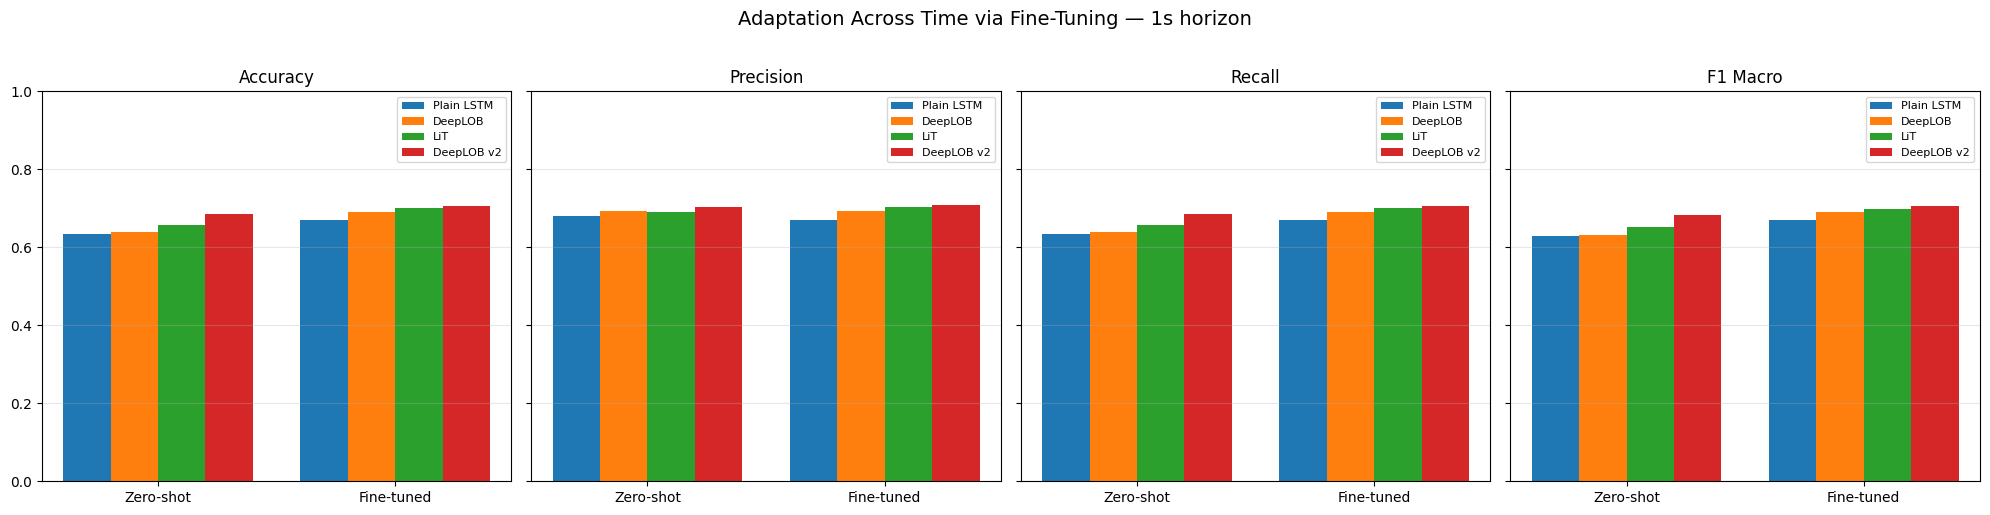

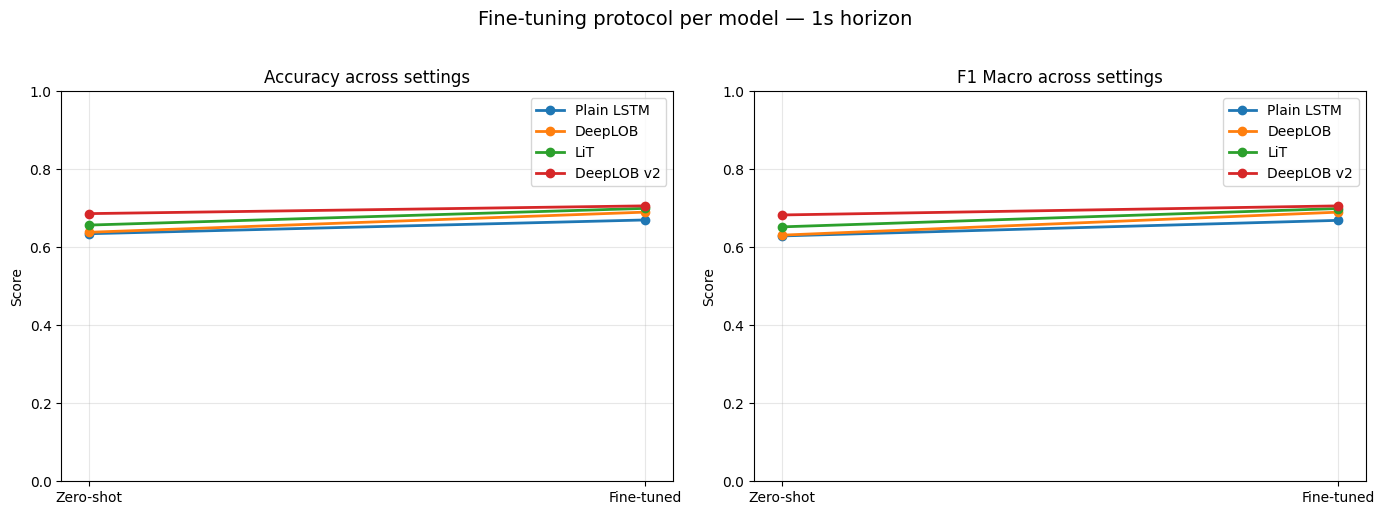

In [ ]:
# fine-tuning setup
rows = []
for model_name, settings in ft_results.items():
    for setting, metrics in settings.items():
        rows.append({"model": model_name, "setting": setting, **metrics})

ft_table = pd.DataFrame(rows)
print("Fine-tuning results table:")
display(ft_table.round(4))

# plots
metrics_to_plot = ["accuracy", "precision", "recall", "f1_macro"]
setting_order = ["Zero-shot", "Fine-tuned"]
model_names = list(ft_results.keys())

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

x = np.arange(len(setting_order))
width = 0.20

for ax, metric in zip(axes, metrics_to_plot):
    for i, model_name in enumerate(model_names):
        vals = [ft_table[(ft_table["model"] == model_name) &
                         (ft_table["setting"] == s)][metric].iloc[0]
                for s in setting_order]
        ax.bar(x + i * width, vals, width, label=model_name)
    ax.set_xticks(x + 1.5 * width)
    ax.set_xticklabels(setting_order)
    ax.set_title(metric.replace("_", " ").title())
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle(f"Adaptation Across Time via Fine-Tuning — {FT_LABEL} horizon",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ["accuracy", "f1_macro"]):
    for model_name in model_names:
        vals = [ft_table[(ft_table["model"] == model_name) &
                         (ft_table["setting"] == s)][metric].iloc[0]
                for s in setting_order]
        ax.plot(setting_order, vals, marker="o", linewidth=2, label=model_name)
    ax.set_title(f"{metric.replace('_', ' ').title()} across settings")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle(f"Fine-tuning protocol per model — {FT_LABEL} horizon",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 12. Attention & saliency analysis

This section looks at what each model focuses on when making predictions using two techniques. For LiT, attention weights are extracted directly from the multi-head attention layers inside the Transformer blocks, giving an idea of which patch tokens the model attends to at each step.

For DeepLOB, gradient times input saliency is computed instead. The gradient of the predicted class logit with respect to the input is multiplied elementwise by the input itself, with higher absolute values indicating timesteps and LOB features that most influenced the prediction. For each sample the gradient is taken with respect to that sample's own predicted class, so the saliency reflects what drove the model's actual decision rather than a fixed reference class.

DeepLOB v2 uses both measures. Its axial attention weights are extracted directly from the level and time attention layers, while gradient times input saliency is computed in the same way as for DeepLOB. This allows the axial attention weights to be compared directly against the saliency for the same model.

Saliency is computed with respect to the pre-softmax logits rather than the softmax output to avoid saturation effects, where the gradient of a confident prediction becomes very small even when the input feature is highly influential. All analysis is run on a sample of 200 test examples at the 1s horizon and averaged across samples to give a stable aggregate picture rather than a single instance explanation.

Attention/saliency: 1s
Gradient × input
Extracting LiT attention weights


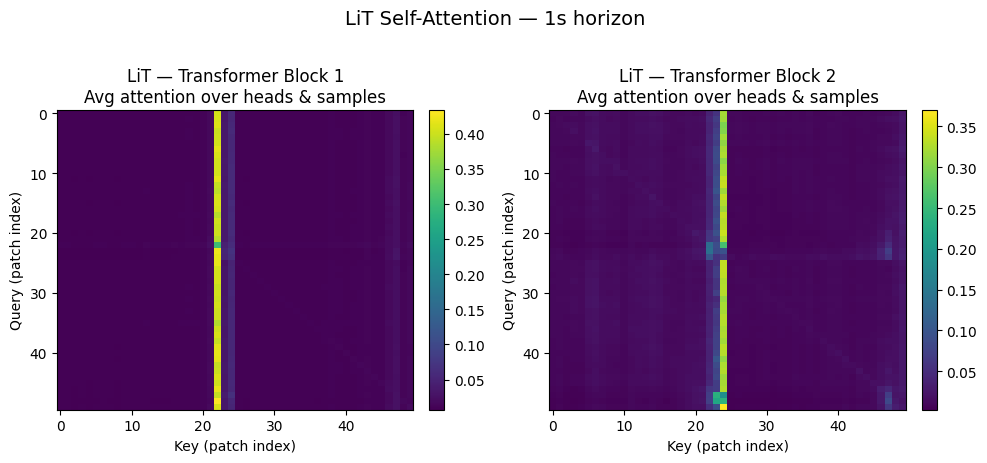

Computing DeepLOB saliency
  Saliency shape: (50, 40)
Computing DeepLOB v2 saliency and axial attention


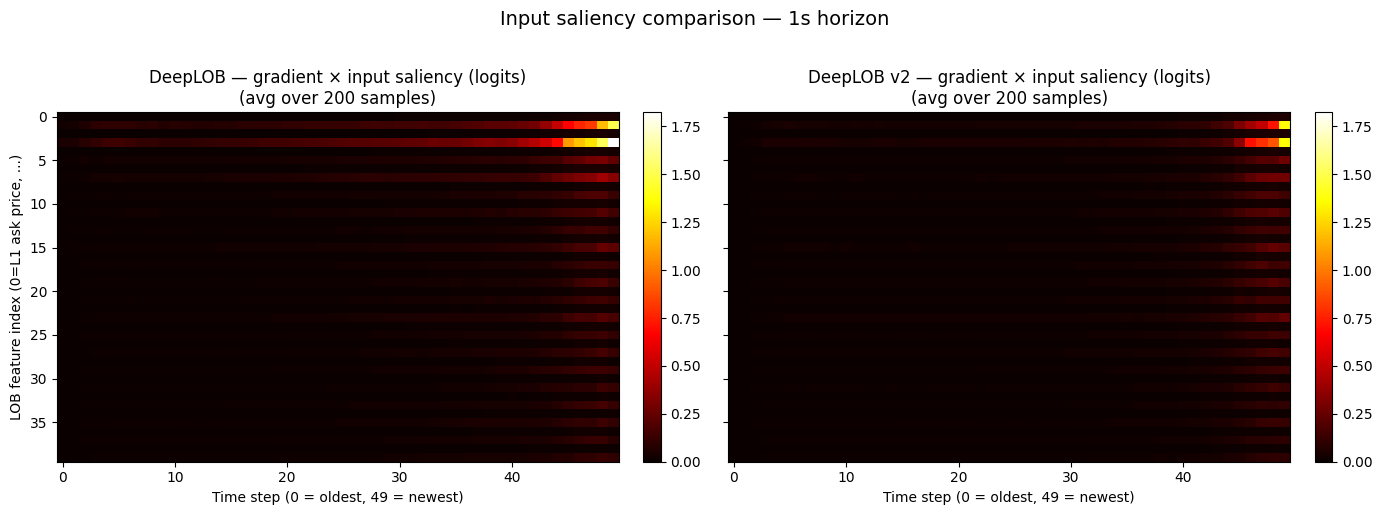

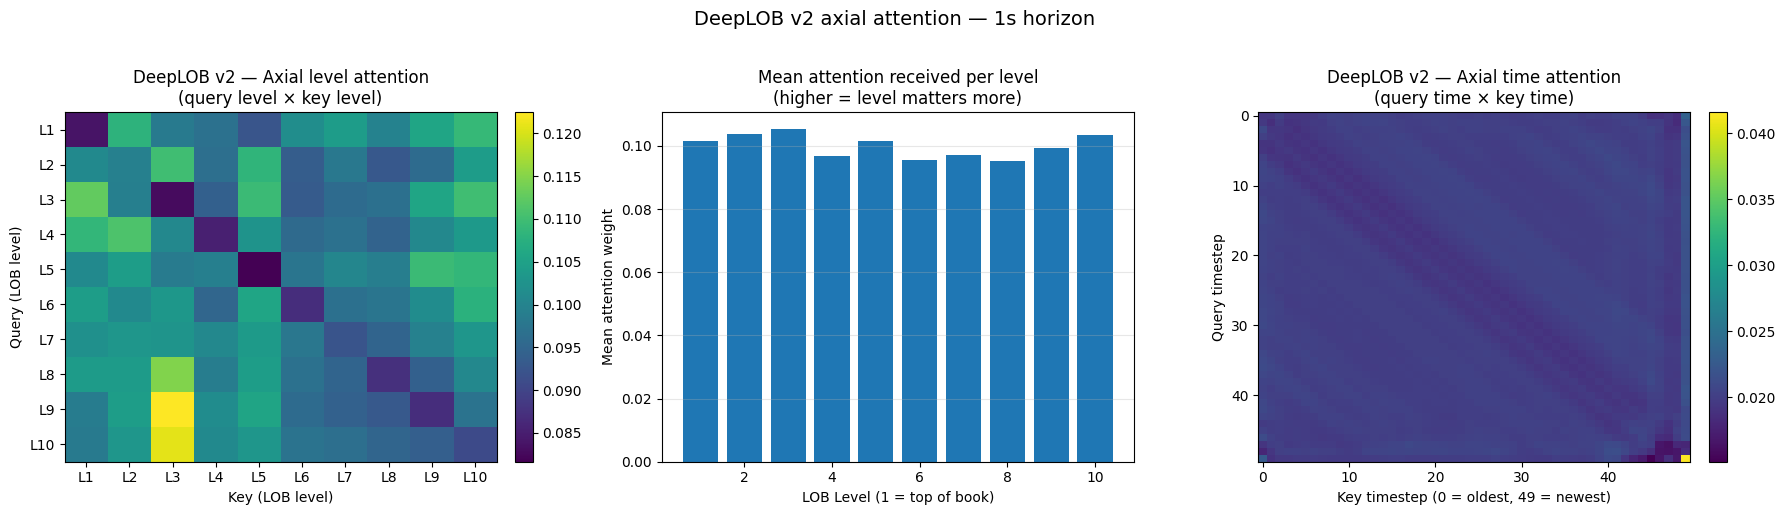


DeepLOB saliency summary
  Saliency on most recent 10 timesteps:  1.0012e-01
  Saliency on most distant 10 timesteps: 1.1430e-02
  Recency ratio: 8.76x

DeepLOB v2 saliency summary
  Saliency on most recent 10 timesteps:  7.6041e-02
  Saliency on most distant 10 timesteps: 8.4369e-03
  Recency ratio: 9.01x

DeepLOB v2 axial-level attention summary
  Level  1: mean attention received = 0.1015
  Level  2: mean attention received = 0.1038
  Level  3: mean attention received = 0.1054
  Level  4: mean attention received = 0.0969
  Level  5: mean attention received = 0.1017
  Level  6: mean attention received = 0.0957
  Level  7: mean attention received = 0.0970
  Level  8: mean attention received = 0.0951
  Level  9: mean attention received = 0.0994
  Level 10: mean attention received = 0.1035
  Most-attended level:  L3
  Least-attended level: L8

DeepLOB v2 axial-time attention summary
  Avg attention to most recent 10 timesteps:  0.0202
  Avg attention to most distant 10 timesteps: 0.020

In [ ]:
# attention and saliency plots
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Model, layers

ATTN_K = FT_K
ATTN_LABEL = HORIZON_LABELS[ATTN_K]
N_SAMPLES = 200

print(f"Attention/saliency: {ATTN_LABEL}")
print("Gradient × input")

def build_pre_softmax_model(softmax_model):
    final_dense = None

    for layer in reversed(softmax_model.layers):
        if isinstance(layer, layers.Dense):
            act = getattr(layer, "activation", None)
            if act is not None and getattr(act, "__name__", "") == "softmax":
                final_dense = layer
                break

    if final_dense is None:
        raise ValueError("Final softmax layer not found.")

    pre_model = Model(
        inputs=softmax_model.inputs,
        outputs=final_dense.input,
        name=f"{softmax_model.name}_pre_softmax"
    )

    return pre_model, final_dense

def gradient_x_input_saliency_logits(softmax_model, X_sample):
    pre_model, final_dense = build_pre_softmax_model(softmax_model)

    kernel, bias = final_dense.get_weights()
    kernel = tf.convert_to_tensor(kernel, dtype=tf.float32)
    bias = tf.convert_to_tensor(bias, dtype=tf.float32)

    X_tf = tf.convert_to_tensor(X_sample, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(X_tf)

        pre_features = pre_model(X_tf, training=False)
        logits = tf.matmul(pre_features, kernel) + bias

        pred_class = tf.argmax(logits, axis=1)
        idx = tf.stack(
            [tf.range(tf.shape(logits)[0], dtype=tf.int64), pred_class],
            axis=1
        )

        chosen_logit = tf.gather_nd(logits, idx)

    grads = tape.gradient(chosen_logit, X_tf)

    if grads is None:
        raise ValueError(
            "Gradient is None. This usually means the saliency path is disconnected."
        )

    sal = np.abs(grads.numpy() * X_sample)
    return sal.mean(axis=0)

# 1. LiT — extract per-block attention scores
print("Extracting LiT attention weights")

def extract_lit_attention(lit_model, X_sample):
    transformer_blocks = [
        l for l in lit_model.layers
        if l.__class__.__name__ == "TransformerBlock"
    ]

    patch_emb_layer = next(
        l for l in lit_model.layers
        if l.__class__.__name__ == "StructuredPatchEmbedding"
    )

    inp = lit_model.input
    x = patch_emb_layer(inp)

    attn_outputs = []

    for blk in transformer_blocks:
        attn_out, attn_scores = blk.attn(
            x, x,
            return_attention_scores=True,
            training=False
        )

        attn_out = blk.d1(attn_out, training=False)
        x_attended = blk.ln1(x + attn_out)

        ffn_out = blk.ffn(x_attended)
        ffn_out = blk.d2(ffn_out, training=False)

        x = blk.ln2(x_attended + ffn_out)
        attn_outputs.append(attn_scores)

    attn_extractor = Model(inputs=inp, outputs=attn_outputs)
    scores_list = attn_extractor(X_sample, training=False)

    if not isinstance(scores_list, list):
        scores_list = [scores_list]

    return [s.numpy().mean(axis=(0, 1)) for s in scores_list]

X_lit, y_lit = create_lit_dataset(
    lob_normalised,
    all_labels[ATTN_K],
    ft_test_mask,
    T=T,
    k=ATTN_K
)

sample_lit = X_lit[:N_SAMPLES]
lit_attentions = extract_lit_attention(ft_pretrained["LiT"], sample_lit)

# plots
n_blocks = len(lit_attentions)
fig, axes = plt.subplots(1, n_blocks, figsize=(5 * n_blocks, 4.5), squeeze=False)

for i, attn in enumerate(lit_attentions):
    ax = axes[0, i]
    im = ax.imshow(attn, cmap="viridis", aspect="auto")
    ax.set_title(f"LiT — Transformer Block {i+1}\nAvg attention over heads & samples")
    ax.set_xlabel("Key (patch index)")
    ax.set_ylabel("Query (patch index)")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f"LiT Self-Attention — {ATTN_LABEL} horizon", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

del X_lit, y_lit, sample_lit

# 2. DeepLOB — gradient × input saliency w.r.t. logits
print("Computing DeepLOB saliency")

X_dl, y_dl = create_deeplob_dataset(
    lob_normalised,
    all_labels[ATTN_K],
    ft_test_mask,
    T=T,
    k=ATTN_K
)

sample_dl = X_dl[:N_SAMPLES]

saliency_dl = gradient_x_input_saliency_logits(
    ft_pretrained["DeepLOB"],
    sample_dl
)

saliency_dl_2d = saliency_dl.squeeze(-1) if saliency_dl.ndim == 3 else saliency_dl

print(f"  Saliency shape: {saliency_dl_2d.shape}")

del X_dl, y_dl, sample_dl

# DeepLOB v2 axial attention
print("Computing DeepLOB v2 saliency and axial attention")

X_dlv2, y_dlv2 = create_deeplob_dataset(
    lob_normalised,
    all_labels[ATTN_K],
    ft_test_mask,
    T=T,
    k=ATTN_K
)

sample_dlv2 = X_dlv2[:N_SAMPLES]

saliency_dlv2 = gradient_x_input_saliency_logits(
    ft_pretrained["DeepLOB v2"],
    sample_dlv2
)

saliency_dlv2_2d = (
    saliency_dlv2.squeeze(-1)
    if saliency_dlv2.ndim == 3
    else saliency_dlv2
)

# DeepLOB v2 axial attention
def extract_axial_attention(model, X_sample):
    axial_level = model.get_layer("axial_level")
    axial_time = model.get_layer("axial_time")

    pre_axial_model = Model(inputs=model.input, outputs=axial_level.input)
    pre_axial = tf.cast(pre_axial_model(X_sample, training=False), tf.float32)

    # Level attention
    shp = tf.shape(pre_axial)
    B, T_, L_, D_ = shp[0], shp[1], shp[2], shp[3]

    x_r = tf.reshape(pre_axial, (B * T_, L_, D_))

    _, level_scores = axial_level.attn(
        x_r, x_r,
        return_attention_scores=True,
        training=False
    )

    level_scores = tf.reshape(level_scores, (B, T_, -1, L_, L_))
    level_avg = tf.reduce_mean(level_scores, axis=[0, 1, 2]).numpy()

    # Time attention
    post_level = axial_level(pre_axial, training=False)
    post_level_t = tf.transpose(post_level, [0, 2, 1, 3])

    shp2 = tf.shape(post_level_t)
    B2, L2, T2, D2 = shp2[0], shp2[1], shp2[2], shp2[3]

    x_r2 = tf.reshape(post_level_t, (B2 * L2, T2, D2))

    _, time_scores = axial_time.attn(
        x_r2, x_r2,
        return_attention_scores=True,
        training=False
    )

    time_scores = tf.reshape(time_scores, (B2, L2, -1, T2, T2))
    time_avg = tf.reduce_mean(time_scores, axis=[0, 1, 2]).numpy()

    return level_avg, time_avg

level_attn, time_attn = extract_axial_attention(
    ft_pretrained["DeepLOB v2"],
    sample_dlv2
)

del X_dlv2, y_dlv2, sample_dlv2

# plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

vmax = max(
    float(saliency_dl_2d.max()),
    float(saliency_dlv2_2d.max())
)

im0 = axes[0].imshow(
    saliency_dl_2d.T,
    aspect="auto",
    cmap="hot",
    vmin=0,
    vmax=vmax
)

axes[0].set_title(
    f"DeepLOB — gradient × input saliency (logits)\n"
    f"(avg over {N_SAMPLES} samples)"
)
axes[0].set_xlabel(f"Time step (0 = oldest, {T-1} = newest)")
axes[0].set_ylabel("LOB feature index (0=L1 ask price, ...)")

fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(
    saliency_dlv2_2d.T,
    aspect="auto",
    cmap="hot",
    vmin=0,
    vmax=vmax
)

axes[1].set_title(
    f"DeepLOB v2 — gradient × input saliency (logits)\n"
    f"(avg over {N_SAMPLES} samples)"
)
axes[1].set_xlabel(f"Time step (0 = oldest, {T-1} = newest)")

fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle(f"Input saliency comparison — {ATTN_LABEL} horizon", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# DeepLOB v2 axial attention
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(level_attn, cmap="viridis", aspect="auto")
axes[0].set_title("DeepLOB v2 — Axial level attention\n(query level × key level)")
axes[0].set_xlabel("Key (LOB level)")
axes[0].set_ylabel("Query (LOB level)")
axes[0].set_xticks(range(10))
axes[0].set_yticks(range(10))
axes[0].set_xticklabels([f"L{i+1}" for i in range(10)])
axes[0].set_yticklabels([f"L{i+1}" for i in range(10)])
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

axes[1].bar(range(1, 11), level_attn.mean(axis=0))
axes[1].set_title("Mean attention received per level\n(higher = level matters more)")
axes[1].set_xlabel("LOB Level (1 = top of book)")
axes[1].set_ylabel("Mean attention weight")
axes[1].grid(axis="y", alpha=0.3)

im2 = axes[2].imshow(time_attn, cmap="viridis", aspect="auto")
axes[2].set_title("DeepLOB v2 — Axial time attention\n(query time × key time)")
axes[2].set_xlabel(f"Key timestep (0 = oldest, {T-1} = newest)")
axes[2].set_ylabel("Query timestep")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle(f"DeepLOB v2 axial attention — {ATTN_LABEL} horizon", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Numerical summaries
print("\nDeepLOB saliency summary")

sal_dl_per_t = saliency_dl_2d.mean(axis=1)

print(f"  Saliency on most recent 10 timesteps:  {sal_dl_per_t[-10:].mean():.4e}")
print(f"  Saliency on most distant 10 timesteps: {sal_dl_per_t[:10].mean():.4e}")
print(
    f"  Recency ratio: "
    f"{sal_dl_per_t[-10:].mean() / max(sal_dl_per_t[:10].mean(), 1e-12):.2f}x"
)

print("\nDeepLOB v2 saliency summary")

sal_dlv2_per_t = saliency_dlv2_2d.mean(axis=1)

print(f"  Saliency on most recent 10 timesteps:  {sal_dlv2_per_t[-10:].mean():.4e}")
print(f"  Saliency on most distant 10 timesteps: {sal_dlv2_per_t[:10].mean():.4e}")
print(
    f"  Recency ratio: "
    f"{sal_dlv2_per_t[-10:].mean() / max(sal_dlv2_per_t[:10].mean(), 1e-12):.2f}x"
)

print("\nDeepLOB v2 axial-level attention summary")

attn_per_level = level_attn.mean(axis=0)

for i, w in enumerate(attn_per_level):
    print(f"  Level {i+1:2d}: mean attention received = {w:.4f}")

print(f"  Most-attended level:  L{int(np.argmax(attn_per_level)) + 1}")
print(f"  Least-attended level: L{int(np.argmin(attn_per_level)) + 1}")

print("\nDeepLOB v2 axial-time attention summary")

recent_w = time_attn[:, -10:].mean()
distant_w = time_attn[:, :10].mean()

print(f"  Avg attention to most recent 10 timesteps:  {recent_w:.4f}")
print(f"  Avg attention to most distant 10 timesteps: {distant_w:.4f}")
print(f"  Recency ratio: {recent_w / max(distant_w, 1e-12):.2f}x")

In [15]:
from statsmodels.stats.contingency_tables import mcnemar

print("Accuracy check:")
print(f"{'k':>3} {'OFI':>8} {'LSTM':>8} {'DeepLOB':>8} {'LiT':>8} {'DLv2':>8}")
for k in HORIZONS:
    print(f"{k:>3} {ofi_results[k]['accuracy']:>8.4f} {lstm_results[k]['accuracy']:>8.4f} "
          f"{deeplob_results[k]['accuracy']:>8.4f} {lit_results[k]['accuracy']:>8.4f} "
          f"{deeplob_v2_results[k]['accuracy']:>8.4f}")


def mcnemar_pair(y_true, yp_A, yp_B):
    A_ok = (yp_A == y_true)
    B_ok = (yp_B == y_true)
    b = int((A_ok & ~B_ok).sum())
    c = int((~A_ok & B_ok).sum())
    res = mcnemar([[0, b], [c, 0]], exact=False, correction=True)
    return b, c, float(res.statistic), float(res.pvalue)


preds = {}
for k in HORIZONS:
    preds[("OFI Linear", k)] = (ofi_results[k]["y_test"],        ofi_results[k]["y_pred"])
    preds[("Plain LSTM", k)] = (lstm_results[k]["y_test"],       lstm_results[k]["y_pred"])
    preds[("DeepLOB",    k)] = (deeplob_results[k]["y_test"],    deeplob_results[k]["y_pred"])
    preds[("LiT",        k)] = (lit_results[k]["y_test"],        lit_results[k]["y_pred"])
    preds[("DeepLOB v2", k)] = (deeplob_v2_results[k]["y_test"], deeplob_v2_results[k]["y_pred"])

pairs = [
    ("DeepLOB v2", "DeepLOB"),
    ("DeepLOB v2", "LiT"),
    ("DeepLOB v2", "Plain LSTM"),
    ("DeepLOB",    "Plain LSTM"),
    ("LiT",        "DeepLOB"),
    ("LiT",        "Plain LSTM"),
    ("Plain LSTM", "OFI Linear"),
]

rows = []
for k in HORIZONS:
    for A, B in pairs:
        yt_A, yp_A = preds[(A, k)]
        yt_B, yp_B = preds[(B, k)]
        if not np.array_equal(yt_A, yt_B):
            print(f"test sets differ for {A} vs {B} at k={k}")
            continue
        yt = np.asarray(yt_A)
        yp_A = np.asarray(yp_A)
        yp_B = np.asarray(yp_B)
        b, c, chi2, pval = mcnemar_pair(yt, yp_A, yp_B)
        acc_A = float((yp_A == yt).mean())
        acc_B = float((yp_B == yt).mean())
        rows.append({
            "horizon": HORIZON_LABELS[k], "A": A, "B": B,
            "acc_A": acc_A, "acc_B": acc_B,
            "delta_pp": (acc_A - acc_B) * 100,
            "b": b, "c": c, "chi2": chi2, "p_value": pval,
        })

mcnemar_df = pd.DataFrame(rows)

def fmt_p(p):
    if p == 0.0:  return "< 1e-300"
    if p < 1e-4:  return f"{p:.2e}"
    return f"{p:.4f}"

show = mcnemar_df.copy()
show["acc_A"]    = show["acc_A"].apply(lambda x: f"{x:.4f}")
show["acc_B"]    = show["acc_B"].apply(lambda x: f"{x:.4f}")
show["delta_pp"] = show["delta_pp"].apply(lambda x: f"{x:+.2f}")
show["chi2"]     = show["chi2"].apply(lambda x: f"{x:.1f}")
show["p_value"]  = show["p_value"].apply(fmt_p)

print("\nMcNemar pairwise comparisons (continuity correction):\n")
print(show.to_string(index=False))

mcnemar_df.to_csv(f"{CHECKPOINT_DIR}/mcnemar_results.csv", index=False)
print(f"\nSaved to {CHECKPOINT_DIR}/mcnemar_results.csv")

Accuracy check:
  k      OFI     LSTM  DeepLOB      LiT     DLv2
  4   0.4304   0.6390   0.6408   0.6608   0.6846
  8   0.4102   0.5841   0.6973   0.6456   0.6899
 20   0.4013   0.6018   0.6531   0.6329   0.6618

McNemar pairwise comparisons (continuity correction):

horizon          A          B  acc_A  acc_B delta_pp      b     c    chi2   p_value
     1s DeepLOB v2    DeepLOB 0.6846 0.6408    +4.38  35111 20004  4140.3  < 1e-300
     1s DeepLOB v2        LiT 0.6846 0.6608    +2.38  30627 22415  1271.1 2.18e-278
     1s DeepLOB v2 Plain LSTM 0.6846 0.6390    +4.56  37420 21699  4180.0  < 1e-300
     1s    DeepLOB Plain LSTM 0.6408 0.6390    +0.18  30860 30246     6.1    0.0131
     1s        LiT    DeepLOB 0.6608 0.6408    +2.00  32671 25776   813.2 7.40e-179
     1s        LiT Plain LSTM 0.6608 0.6390    +2.18  32622 25113   976.4 2.47e-214
     1s Plain LSTM OFI Linear 0.6390 0.4304   +20.86 112623 40737 33694.9  < 1e-300
     2s DeepLOB v2    DeepLOB 0.6899 0.6973    -0.74  22038 